# Exploratory Data Analysis — FIFA World Cup Dataset
**Hybrid Graph-Text Architecture for Sports Match Outcome Prediction**

This notebook performs a comprehensive EDA across all processed datasets:
- `match_dataset` — all 22 World Cups (1930–2022), 964 matches, 105 features
- `match_dataset_1994_2022` — 500 matches with FIFA rankings
- `match_dataset_1994_2022_with_text` — 500 matches + article text availability
- `fifa_rankings_clean` — 13,128 ranking records
- `worldcup_matches_clean` — base match records
- `team_tournament_features` — pre-tournament team stats
- `teams`, `tournaments` — reference tables
- `articles_with_flags`, `pre_match_articles` — 994 news articles

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

BASE = Path('data/processed')
PAR  = BASE / 'parquet'
TXT  = BASE / 'text'

# ── Load all datasets ────────────────────────────────────────────────────────
df_all   = pd.read_parquet(PAR / 'match_dataset.parquet')
df94     = pd.read_parquet(PAR / 'match_dataset_1994_2022.parquet')
df_text  = pd.read_parquet(BASE / 'match_dataset_1994_2022_with_text.parquet')
df_rank  = pd.read_parquet(PAR / 'fifa_rankings_clean.parquet')
df_wc    = pd.read_parquet(PAR / 'worldcup_matches_clean.parquet')
df_teams = pd.read_parquet(PAR / 'teams.parquet')
df_tourn = pd.read_parquet(PAR / 'tournaments.parquet')
df_ttf   = pd.read_parquet(PAR / 'team_tournament_features.parquet')
df_arts  = pd.read_parquet(TXT / 'articles_with_flags.parquet')
df_pre   = pd.read_parquet(TXT / 'pre_match_articles.parquet')

print('All datasets loaded.')

All datasets loaded.


## 1. Dataset Overview

In [2]:
summary = pd.DataFrame([
    {'Dataset': 'match_dataset (all WC)',         'Rows': len(df_all),   'Cols': df_all.shape[1],   'Years': f"{df_all['tournament_year'].min()}–{df_all['tournament_year'].max()}"},
    {'Dataset': 'match_dataset_1994_2022',        'Rows': len(df94),     'Cols': df94.shape[1],     'Years': '1994–2022'},
    {'Dataset': 'match_dataset_with_text',        'Rows': len(df_text),  'Cols': df_text.shape[1],  'Years': '1994–2022'},
    {'Dataset': 'fifa_rankings_clean',            'Rows': len(df_rank),  'Cols': df_rank.shape[1],  'Years': f"{df_rank['ranking_year'].min()}–{df_rank['ranking_year'].max()}"},
    {'Dataset': 'worldcup_matches_clean',         'Rows': len(df_wc),    'Cols': df_wc.shape[1],    'Years': f"{df_wc['tournament_year'].min()}–{df_wc['tournament_year'].max()}"},
    {'Dataset': 'team_tournament_features',       'Rows': len(df_ttf),   'Cols': df_ttf.shape[1],   'Years': '—'},
    {'Dataset': 'teams',                          'Rows': len(df_teams), 'Cols': df_teams.shape[1], 'Years': '—'},
    {'Dataset': 'tournaments',                    'Rows': len(df_tourn), 'Cols': df_tourn.shape[1], 'Years': '1930–2022'},
    {'Dataset': 'articles_with_flags',            'Rows': len(df_arts),  'Cols': df_arts.shape[1],  'Years': '—'},
    {'Dataset': 'pre_match_articles',             'Rows': len(df_pre),   'Cols': df_pre.shape[1],   'Years': '—'},
])
summary

,Dataset,Rows,Cols,Years
0,match_dataset (all WC),964,105,1930–2022
1,match_dataset_1994_2022,500,105,1994–2022
2,match_dataset_with_text,500,109,1994–2022
3,fifa_rankings_clean,13128,10,1992–2024
4,worldcup_matches_clean,964,25,1930–2022
5,team_tournament_features,489,11,—
6,teams,86,3,—
7,tournaments,22,7,1930–2022
8,articles_with_flags,994,26,—
9,pre_match_articles,994,26,—


Tournaments in dataset:


,tournament_year,tournament_name,num_teams,num_matches,start_date,end_date
0,1930,FIFA World Cup 1930,13,18,1930-07-13,1930-07-30
1,1934,FIFA World Cup 1934,16,17,1934-05-27,1934-06-10
2,1938,FIFA World Cup 1938,15,18,1938-06-04,1938-06-19
3,1950,FIFA World Cup 1950,13,22,1950-06-24,1950-07-16
4,1954,FIFA World Cup 1954,16,26,1954-06-16,1954-07-04
5,1958,FIFA World Cup 1958,16,35,1958-06-08,1958-06-29
6,1962,FIFA World Cup 1962,16,32,1962-05-30,1962-06-17
7,1966,FIFA World Cup 1966,16,32,1966-07-11,1966-07-30
8,1970,FIFA World Cup 1970,16,32,1970-05-31,1970-06-21
9,1974,FIFA World Cup 1974,16,38,1974-06-13,1974-07-07


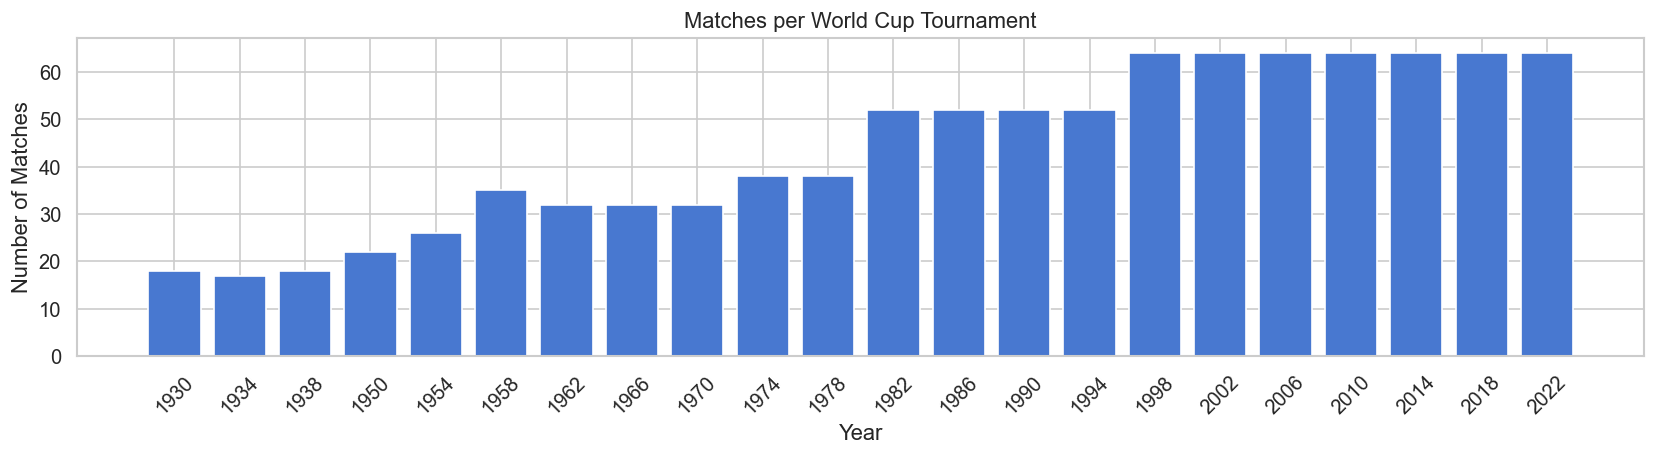

In [3]:
print('Tournaments in dataset:')
display(df_tourn[['tournament_year','tournament_name','num_teams','num_matches','start_date','end_date']])

# Matches per tournament
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df_tourn['tournament_year'].astype(str), df_tourn['num_matches'], color=sns.color_palette('muted')[0])
ax.set_title('Matches per World Cup Tournament')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Target Variable & Match Outcomes

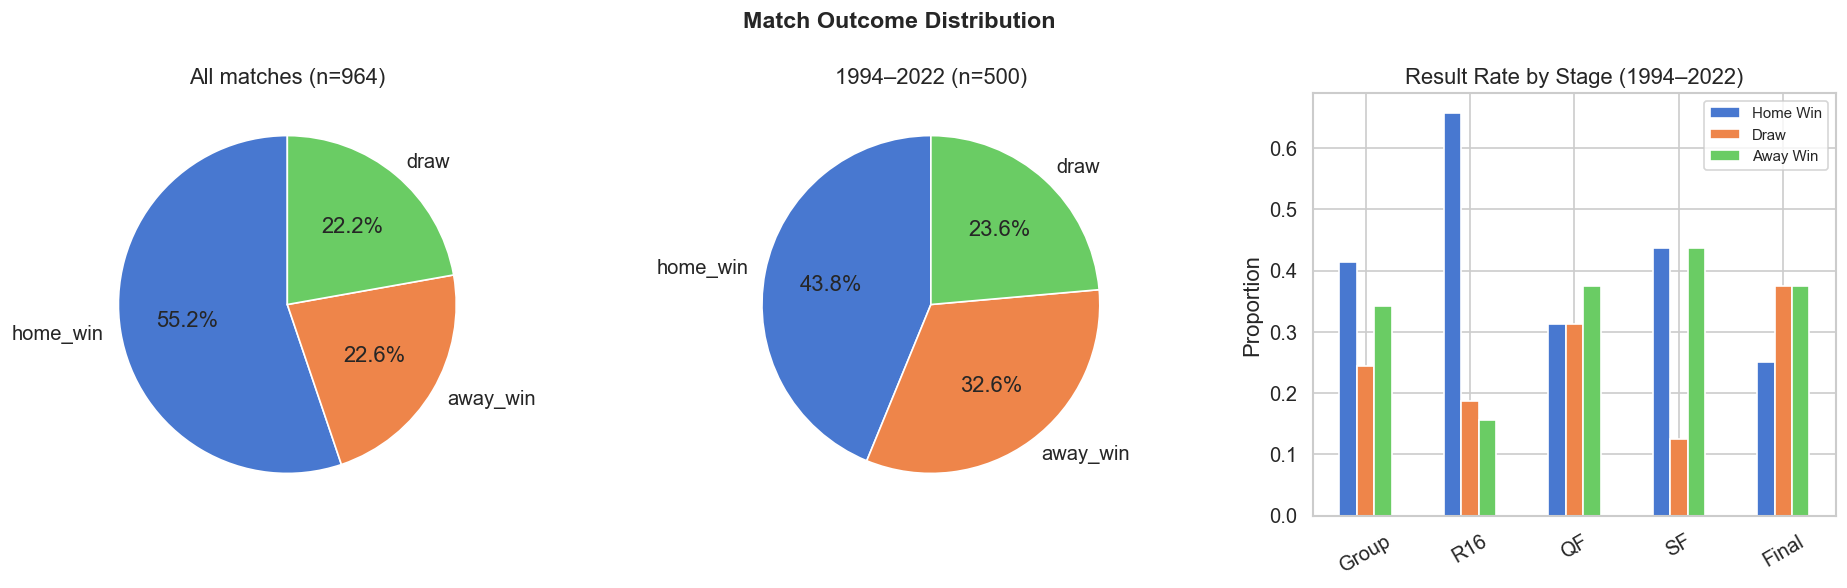


Class counts (target):
target
home_win    219
away_win    163
draw        118
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Full dataset ---
vc_all = df_all['result'].value_counts()
axes[0].pie(vc_all, labels=vc_all.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', 3))
axes[0].set_title(f'All matches (n={len(df_all)})')

# --- 1994–2022 ---
vc_94 = df94['result'].value_counts()
axes[1].pie(vc_94, labels=vc_94.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', 3))
axes[1].set_title(f'1994–2022 (n={len(df94)})')

# --- By stage (1994-2022) ---
stage_map = {'Group stage': 'Group', 'Round of 16': 'R16', 'Quarter-finals': 'QF', 'Semi-finals': 'SF', 'Final': 'Final', 'Third-place match': '3rd'}
stages = ['Group stage', 'Round of 16', 'Quarter-finals', 'Semi-finals', 'Final']
stage_data = df94[df94['stage'].isin(stages)].groupby('stage')['result'].value_counts(normalize=True).unstack().reindex(stages)
stage_data.index = [stage_map.get(s, s) for s in stage_data.index]
stage_data[['home_win','draw','away_win']].plot(kind='bar', ax=axes[2], color=sns.color_palette('muted', 3), edgecolor='white')
axes[2].set_title('Result Rate by Stage (1994–2022)')
axes[2].set_xlabel('')
axes[2].set_ylabel('Proportion')
axes[2].legend(['Home Win', 'Draw', 'Away Win'], loc='upper right', fontsize=9)
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle('Match Outcome Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClass counts (target):')
print(df94['target'].value_counts().rename({0:'home_win', 1:'draw', 2:'away_win'}))

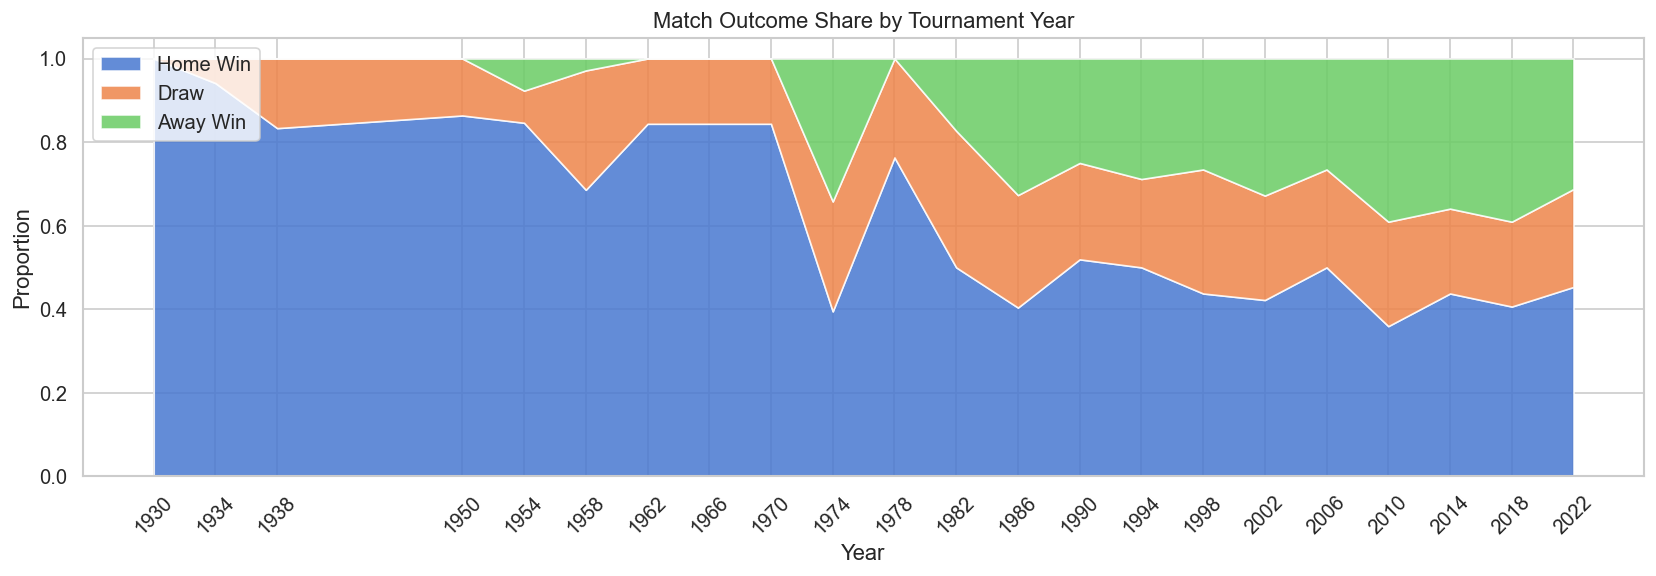

In [5]:
# Home win rate over time
yr_result = df_all.groupby('tournament_year')['result'].value_counts(normalize=True).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(yr_result.index,
             yr_result.get('home_win', pd.Series(0, index=yr_result.index)),
             yr_result.get('draw', pd.Series(0, index=yr_result.index)),
             yr_result.get('away_win', pd.Series(0, index=yr_result.index)),
             labels=['Home Win', 'Draw', 'Away Win'],
             colors=sns.color_palette('muted', 3), alpha=0.85)
ax.set_title('Match Outcome Share by Tournament Year')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion')
ax.legend(loc='upper left')
ax.set_xticks(yr_result.index)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Goals & Scores Analysis

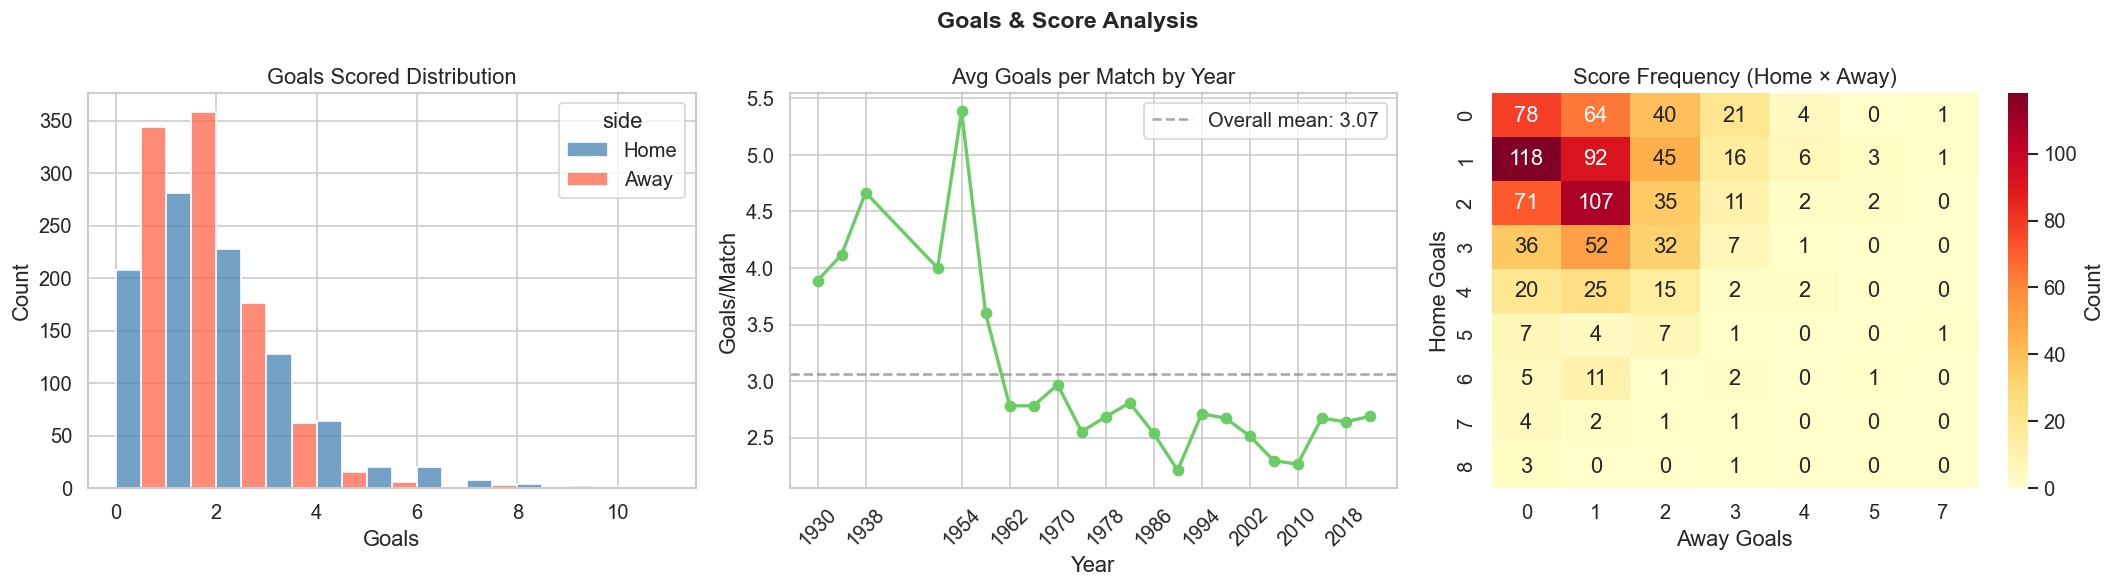

Most common scoreline: (np.int64(1), np.int64(0)) (118 times)
High-scoring matches (>5 goals): 84 (8.7%)
Goalless draws: 78


In [6]:
df_all['total_goals'] = df_all['home_score'] + df_all['away_score']
df_all['goal_diff'] = df_all['home_score'] - df_all['away_score']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Home vs Away goals distribution
goals_long = pd.concat([
    df_all['home_score'].rename('goals').to_frame().assign(side='Home'),
    df_all['away_score'].rename('goals').to_frame().assign(side='Away'),
])
sns.histplot(data=goals_long, x='goals', hue='side', bins=range(0, 12),
             multiple='dodge', ax=axes[0], palette=['steelblue','tomato'])
axes[0].set_title('Goals Scored Distribution')
axes[0].set_xlabel('Goals')

# Total goals per match over years
tg_yr = df_all.groupby('tournament_year')['total_goals'].mean()
axes[1].plot(tg_yr.index, tg_yr.values, 'o-', color=sns.color_palette('muted')[2], linewidth=2)
axes[1].axhline(tg_yr.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Overall mean: {tg_yr.mean():.2f}')
axes[1].set_title('Avg Goals per Match by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Goals/Match')
axes[1].legend()
axes[1].set_xticks(tg_yr.index[::2])
plt.setp(axes[1].get_xticklabels(), rotation=45)

# Score frequency heatmap (home x away)
score_pivot = df_all.groupby(['home_score','away_score']).size().unstack(fill_value=0)
score_pivot = score_pivot.loc[score_pivot.index <= 8, score_pivot.columns[score_pivot.columns <= 7]]
sns.heatmap(score_pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title('Score Frequency (Home × Away)')
axes[2].set_xlabel('Away Goals')
axes[2].set_ylabel('Home Goals')

fig.suptitle('Goals & Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Most common scoreline: {df_all.groupby(['home_score','away_score']).size().idxmax()} ({df_all.groupby(['home_score','away_score']).size().max()} times)")
print(f"High-scoring matches (>5 goals): {(df_all['total_goals']>5).sum()} ({(df_all['total_goals']>5).mean()*100:.1f}%)")
print(f"Goalless draws: {((df_all['home_score']==0) & (df_all['away_score']==0)).sum()}")

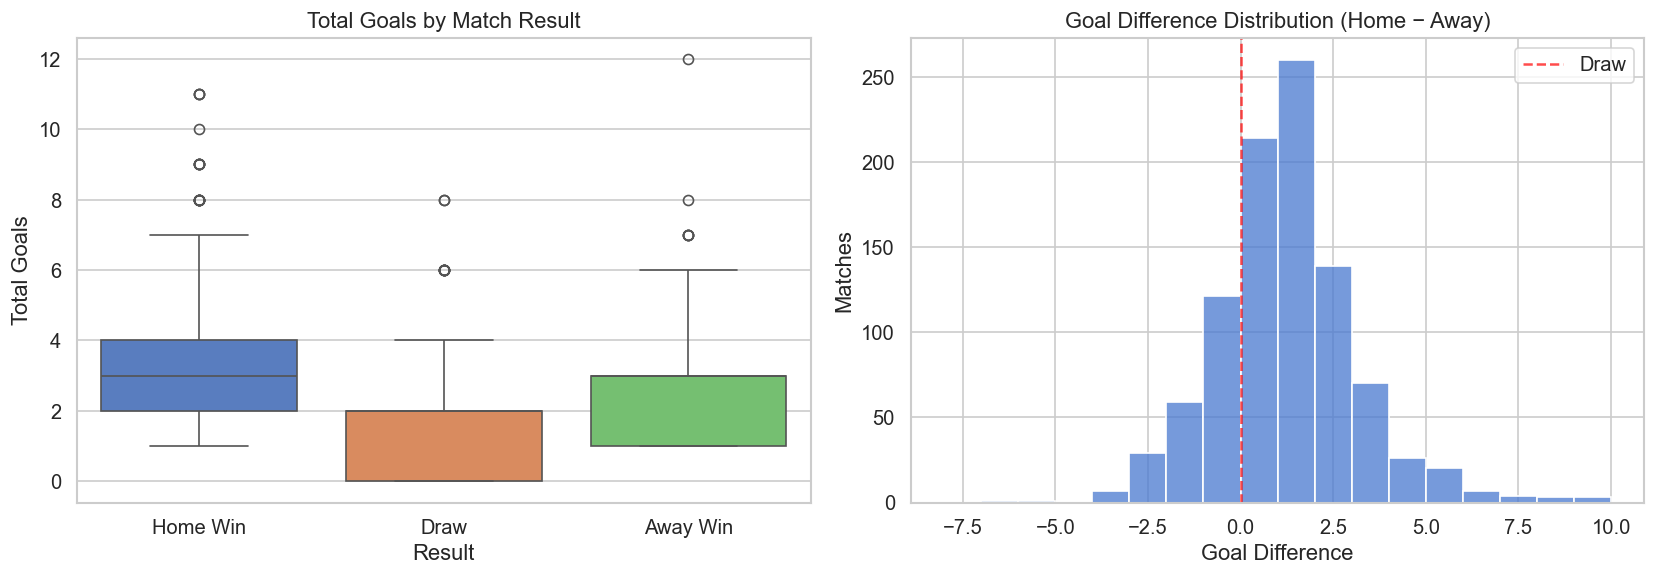

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total goals by result
sns.boxplot(data=df_all, x='result', y='total_goals', order=['home_win','draw','away_win'],
            palette='muted', ax=axes[0])
axes[0].set_title('Total Goals by Match Result')
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Total Goals')
axes[0].set_xticklabels(['Home Win', 'Draw', 'Away Win'])

# Goal difference distribution
sns.histplot(df_all['goal_diff'], bins=range(-8, 11), kde=False, ax=axes[1], color=sns.color_palette('muted')[0])
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='Draw')
axes[1].set_title('Goal Difference Distribution (Home − Away)')
axes[1].set_xlabel('Goal Difference')
axes[1].set_ylabel('Matches')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. FIFA Rankings Analysis

In [8]:
print('FIFA Rankings dataset shape:', df_rank.shape)
print('Years covered:', df_rank['ranking_year'].min(), '–', df_rank['ranking_year'].max())
print('Unique teams ranked:', df_rank['team_norm'].nunique())
print()
display(df_rank.describe())

# Teams ranked most/least
team_count = df_rank.groupby('team_norm').size().sort_values(ascending=False)
print('\nMost frequently ranked teams (top 10):')
print(team_count.head(10).to_string())

FIFA Rankings dataset shape: (13128, 10)
Years covered: 1992 – 2024
Unique teams ranked: 226



,ranking_year,semester,ranking_date,rank,total_points,previous_points,diff_points
count,13128.0,13128.0,13128,13128.000000,13128.000000,13128.000000,13128.000000
mean,2008.695384,1.507389,2009-06-11 23:28:57.477148,101.435938,519.796254,520.116661,-0.320407
min,1992.0,1.0,1992-12-31 00:00:00,1.000000,0.000000,0.000000,-364.000000
25%,2001.0,1.0,2001-06-30 00:00:00,51.000000,68.000000,71.000000,-2.000000
50%,2009.0,2.0,2009-06-30 00:00:00,101.000000,390.000000,393.000000,0.000000
75%,2017.0,2.0,2017-06-30 00:00:00,151.000000,867.000000,864.000000,1.000000
max,2024.0,2.0,2024-12-31 00:00:00,211.000000,2172.000000,2187.000000,822.000000
std,9.2457,0.499964,NaN,58.765826,485.451245,484.189117,40.603076



Most frequently ranked teams (top 10):
team_norm
albania                65
algeria                65
burkina faso           65
angola                 65
argentina              65
antigua and barbuda    65
bangladesh             65
austria                65
australia              65
aruba                  65


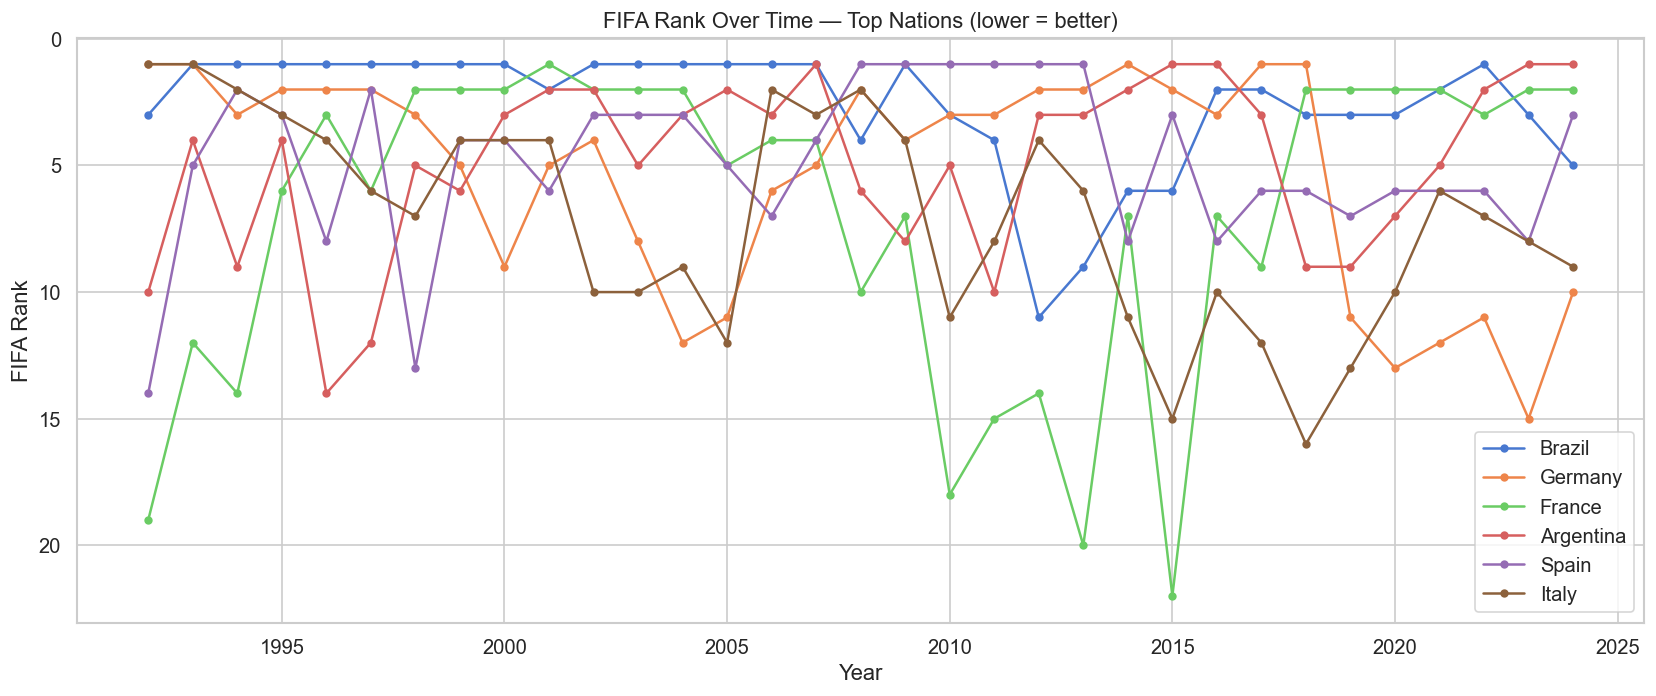

In [9]:
top_teams = ['brazil', 'germany', 'france', 'argentina', 'spain', 'italy']
fig, ax = plt.subplots(figsize=(14, 6))

rank_yr = df_rank.groupby(['ranking_year','team_norm'])['rank'].min().reset_index()
for team in top_teams:
    t = rank_yr[rank_yr['team_norm'] == team]
    if not t.empty:
        ax.plot(t['ranking_year'], t['rank'], 'o-', label=team.title(), linewidth=1.5, markersize=4)

ax.invert_yaxis()
ax.set_title('FIFA Rank Over Time — Top Nations (lower = better)')
ax.set_xlabel('Year')
ax.set_ylabel('FIFA Rank')
ax.legend()
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

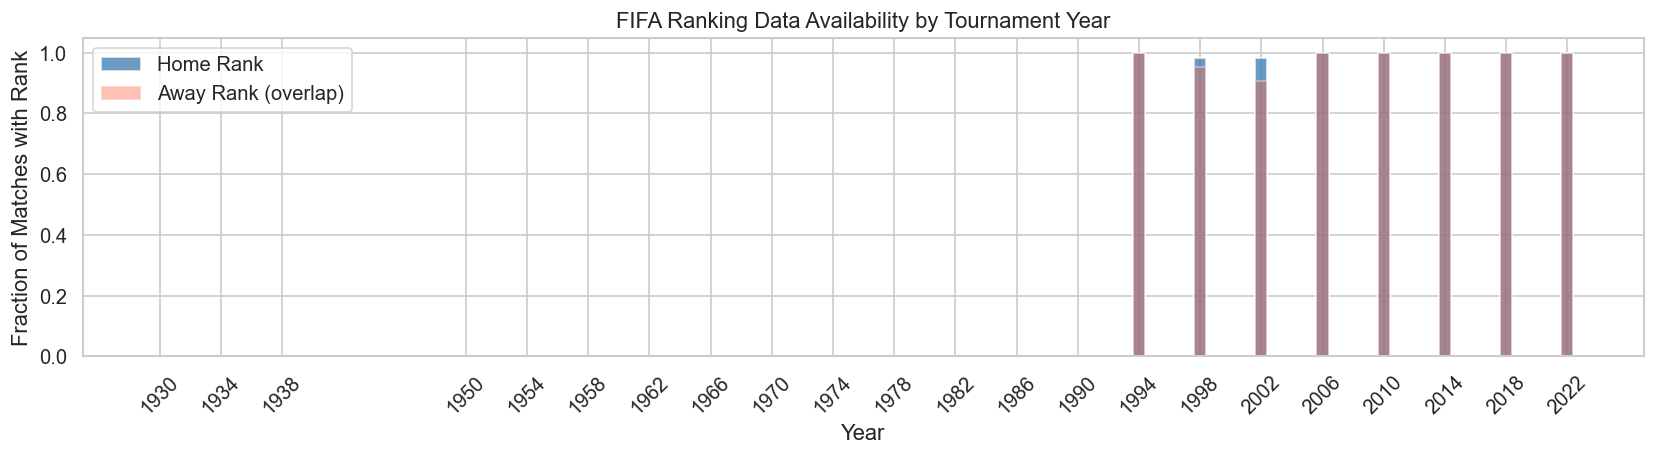

FIFA rankings available only from 1994 onward.


In [10]:
# FIFA rank null coverage in match dataset
rank_coverage = df_all.groupby('tournament_year').apply(
    lambda x: pd.Series({
        'home_rank_available': x['home_fifa_rank'].notna().mean(),
        'away_rank_available': x['away_fifa_rank'].notna().mean(),
    }), include_groups=False
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(rank_coverage.index, rank_coverage['home_rank_available'], label='Home Rank', alpha=0.8, color='steelblue')
ax.bar(rank_coverage.index, rank_coverage['away_rank_available'], bottom=0, label='Away Rank (overlap)', alpha=0.4, color='tomato')
ax.set_title('FIFA Ranking Data Availability by Tournament Year')
ax.set_xlabel('Year')
ax.set_ylabel('Fraction of Matches with Rank')
ax.set_xticks(rank_coverage.index)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('FIFA rankings available only from 1994 onward.')

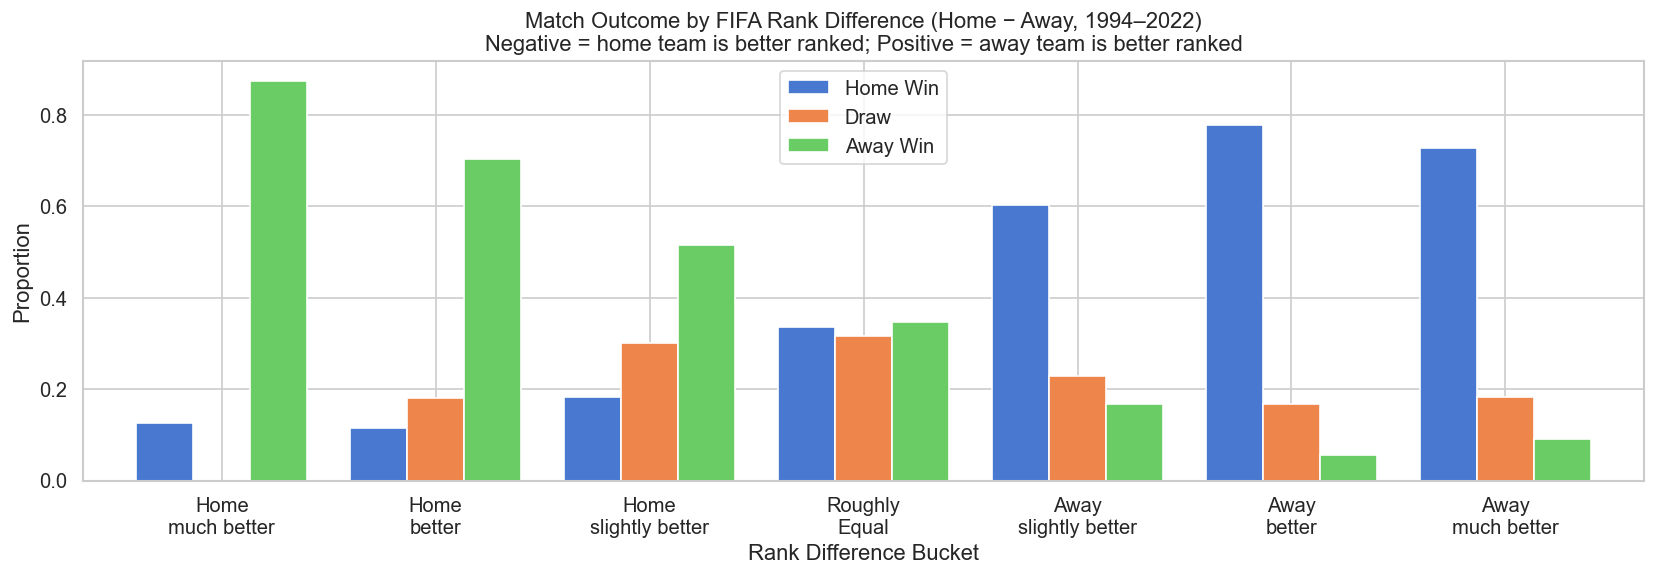

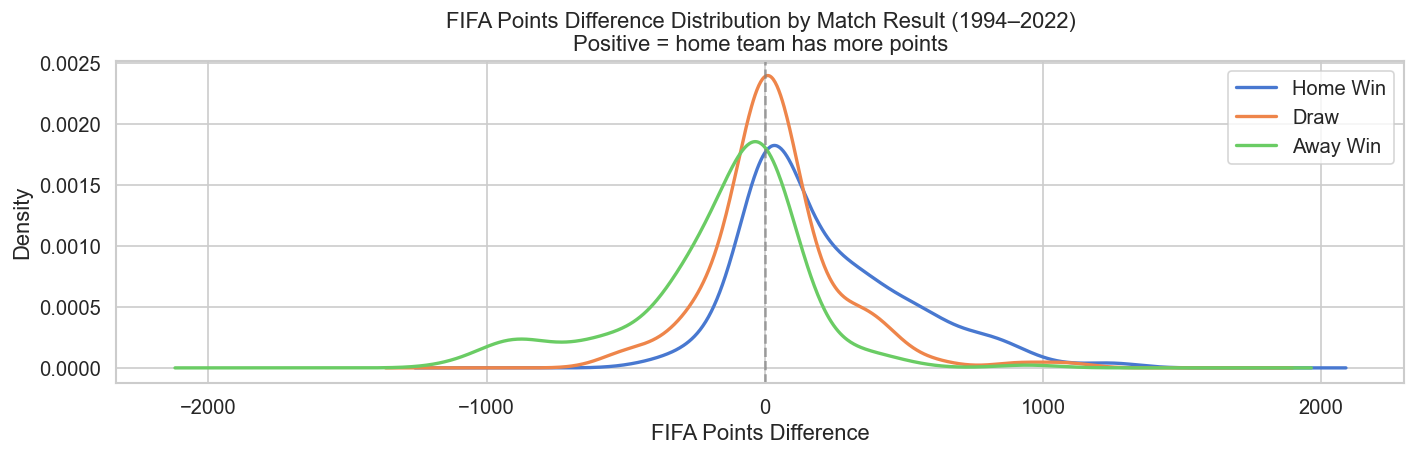

In [11]:
# Rank difference vs outcome (1994-2022)
d = df94.dropna(subset=['fifa_rank_diff']).copy()
bins = [-300, -50, -20, -5, 5, 20, 50, 300]
labels = ['Home\nmuch better', 'Home\nbetter', 'Home\nslightly better', 'Roughly\nEqual',
          'Away\nslightly better', 'Away\nbetter', 'Away\nmuch better']
d['rank_bucket'] = pd.cut(d['fifa_rank_diff'], bins=bins, labels=labels)

bucket_rates = d.groupby('rank_bucket', observed=False)['result'].value_counts(normalize=True).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
bucket_rates[['home_win','draw','away_win']].plot(kind='bar', ax=ax,
    color=sns.color_palette('muted', 3), edgecolor='white', width=0.8)
ax.set_title('Match Outcome by FIFA Rank Difference (Home − Away, 1994–2022)\n'
             'Negative = home team is better ranked; Positive = away team is better ranked')
ax.set_xlabel('Rank Difference Bucket')
ax.set_ylabel('Proportion')
ax.legend(['Home Win', 'Draw', 'Away Win'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Points diff distribution per outcome
fig, ax = plt.subplots(figsize=(12, 4))
for res, color in zip(['home_win', 'draw', 'away_win'], sns.color_palette('muted', 3)):
    subset = d[d['result'] == res]['fifa_points_diff'].dropna()
    subset.plot.kde(ax=ax, label=res, color=color, linewidth=2)
ax.axvline(0, color='gray', linestyle='--', alpha=0.7)
ax.set_title('FIFA Points Difference Distribution by Match Result (1994–2022)\n'
             'Positive = home team has more points')
ax.set_xlabel('FIFA Points Difference')
ax.legend(['Home Win', 'Draw', 'Away Win'])
plt.tight_layout()
plt.show()

## 5. Team Form Features

In [12]:
# Describe form features for 1994-2022 dataset
form_cols = [
    'home_last3_win_rate', 'home_last5_win_rate', 'home_last10_win_rate',
    'away_last3_win_rate', 'away_last5_win_rate', 'away_last10_win_rate',
    'home_wc_win_rate_before', 'away_wc_win_rate_before',
]
display(df94[form_cols].describe().round(3))

,home_last3_win_rate,home_last5_win_rate,home_last10_win_rate,away_last3_win_rate,away_last5_win_rate,away_last10_win_rate,home_wc_win_rate_before,away_wc_win_rate_before
count,491.000,491.000,491.000,482.000,482.000,482.000,491.000,482.000
mean,0.426,0.423,0.407,0.334,0.334,0.350,0.397,0.343
std,0.311,0.263,0.234,0.292,0.255,0.225,0.197,0.199
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.333,0.200,0.200,0.000,0.200,0.200,0.259,0.211
50%,0.333,0.400,0.400,0.333,0.333,0.300,0.429,0.333
75%,0.667,0.600,0.600,0.667,0.475,0.500,0.535,0.483
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


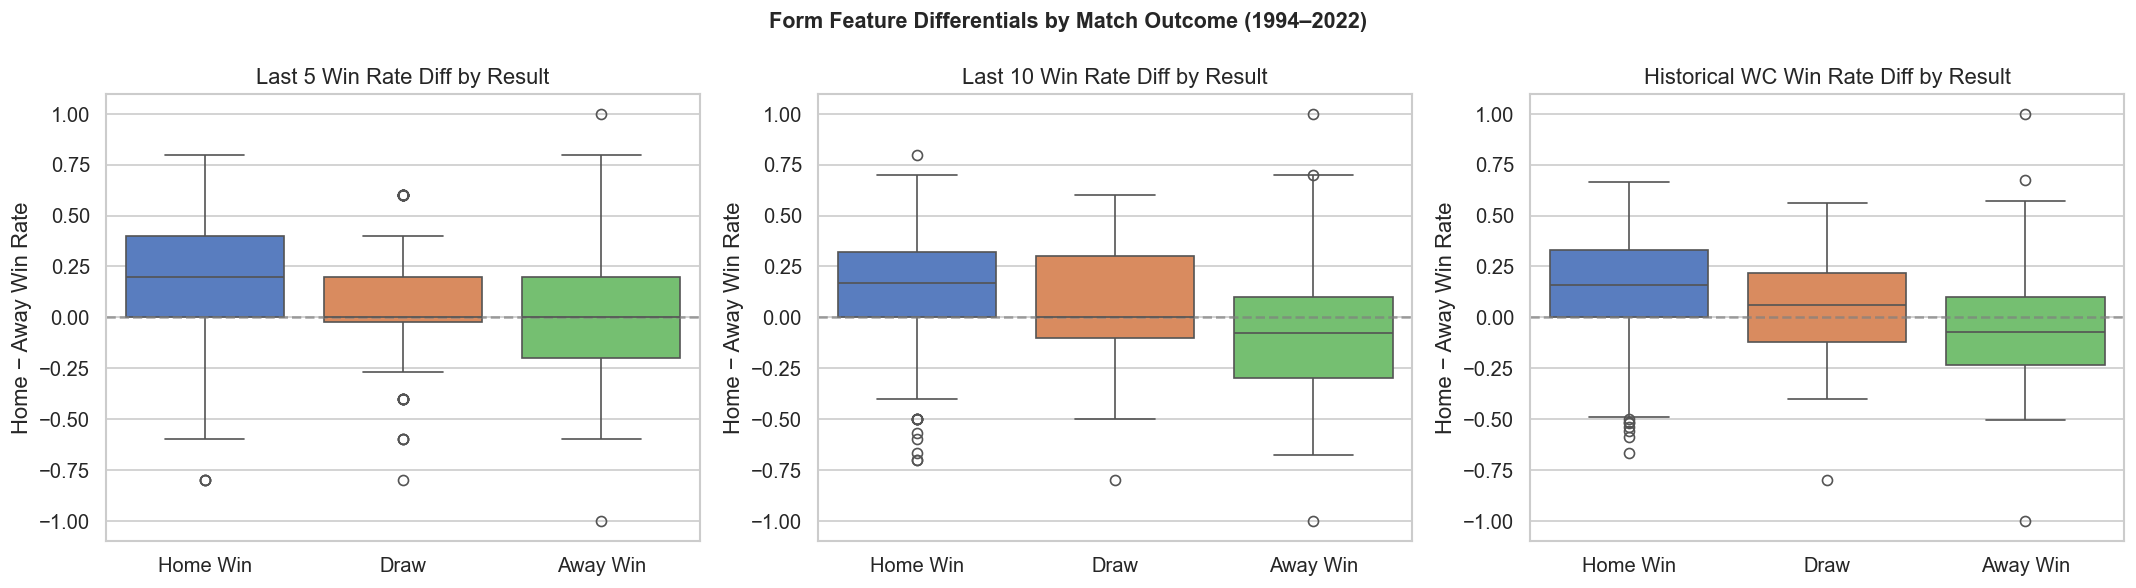

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('home_last5_win_rate', 'away_last5_win_rate', 'Last 5 Win Rate'),
    ('home_last10_win_rate', 'away_last10_win_rate', 'Last 10 Win Rate'),
    ('home_wc_win_rate_before', 'away_wc_win_rate_before', 'Historical WC Win Rate'),
]
result_order = ['home_win', 'draw', 'away_win']
result_labels = ['Home Win', 'Draw', 'Away Win']

for ax, (hcol, acol, title) in zip(axes, pairs):
    d = df94[[hcol, acol, 'result']].dropna()
    d = d.copy()
    d['win_rate_diff'] = d[hcol] - d[acol]
    sns.boxplot(data=d, x='result', y='win_rate_diff', order=result_order,
                palette='muted', ax=ax)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f'{title} Diff by Result')
    ax.set_xlabel('')
    ax.set_ylabel('Home − Away Win Rate')
    ax.set_xticklabels(result_labels)

fig.suptitle('Form Feature Differentials by Match Outcome (1994–2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

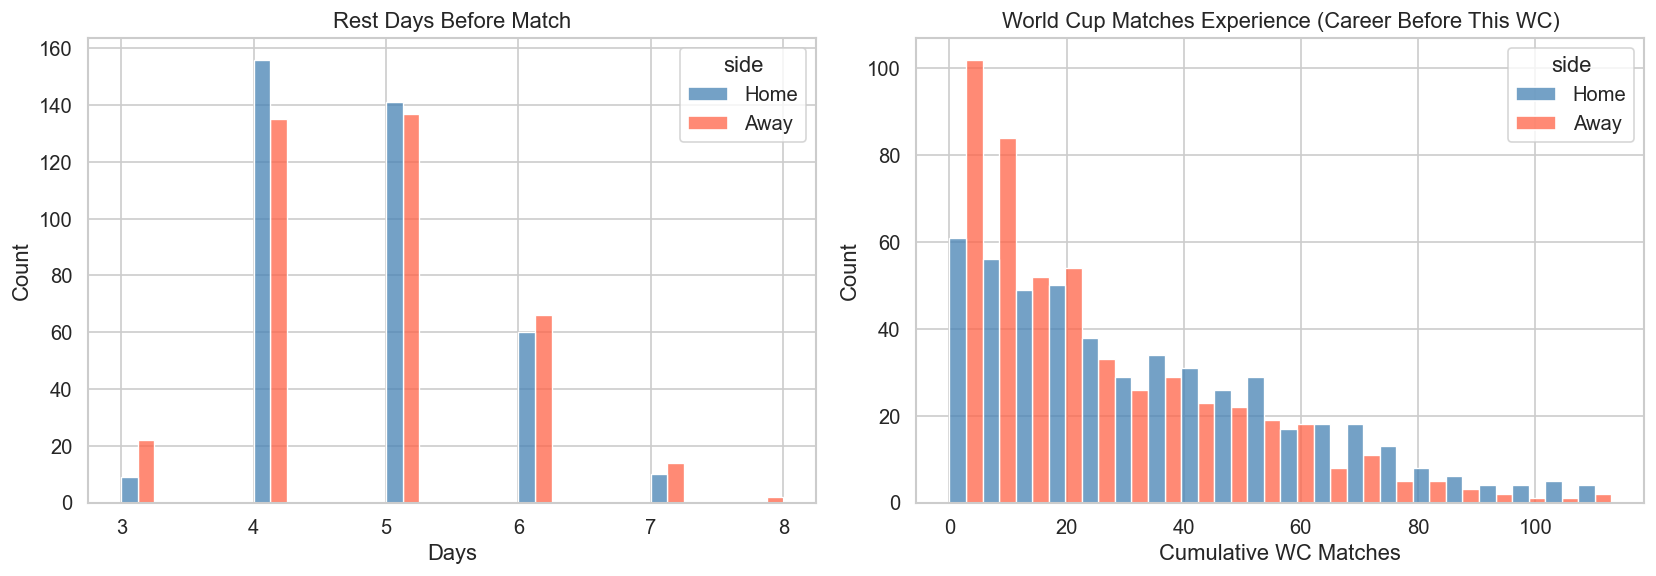

First match in tournament (no rest days):
Home: 124 Away: 124


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rest days distribution
rest = pd.concat([
    df94['home_rest_days'].dropna().rename('rest_days').to_frame().assign(side='Home'),
    df94['away_rest_days'].dropna().rename('rest_days').to_frame().assign(side='Away'),
])
sns.histplot(data=rest, x='rest_days', hue='side', bins=20, multiple='dodge',
             palette=['steelblue','tomato'], ax=axes[0])
axes[0].set_title('Rest Days Before Match')
axes[0].set_xlabel('Days')

# WC experience
wc_exp = pd.concat([
    df94['home_wc_matches_before'].rename('matches').to_frame().assign(side='Home'),
    df94['away_wc_matches_before'].rename('matches').to_frame().assign(side='Away'),
])
sns.histplot(data=wc_exp, x='matches', hue='side', bins=20, multiple='dodge',
             palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_title('World Cup Matches Experience (Career Before This WC)')
axes[1].set_xlabel('Cumulative WC Matches')

plt.tight_layout()
plt.show()

print('First match in tournament (no rest days):')
print('Home:', df94['home_first_match_in_tournament'].sum(), 'Away:', df94['away_first_match_in_tournament'].sum())

## 6. Missing Data Analysis

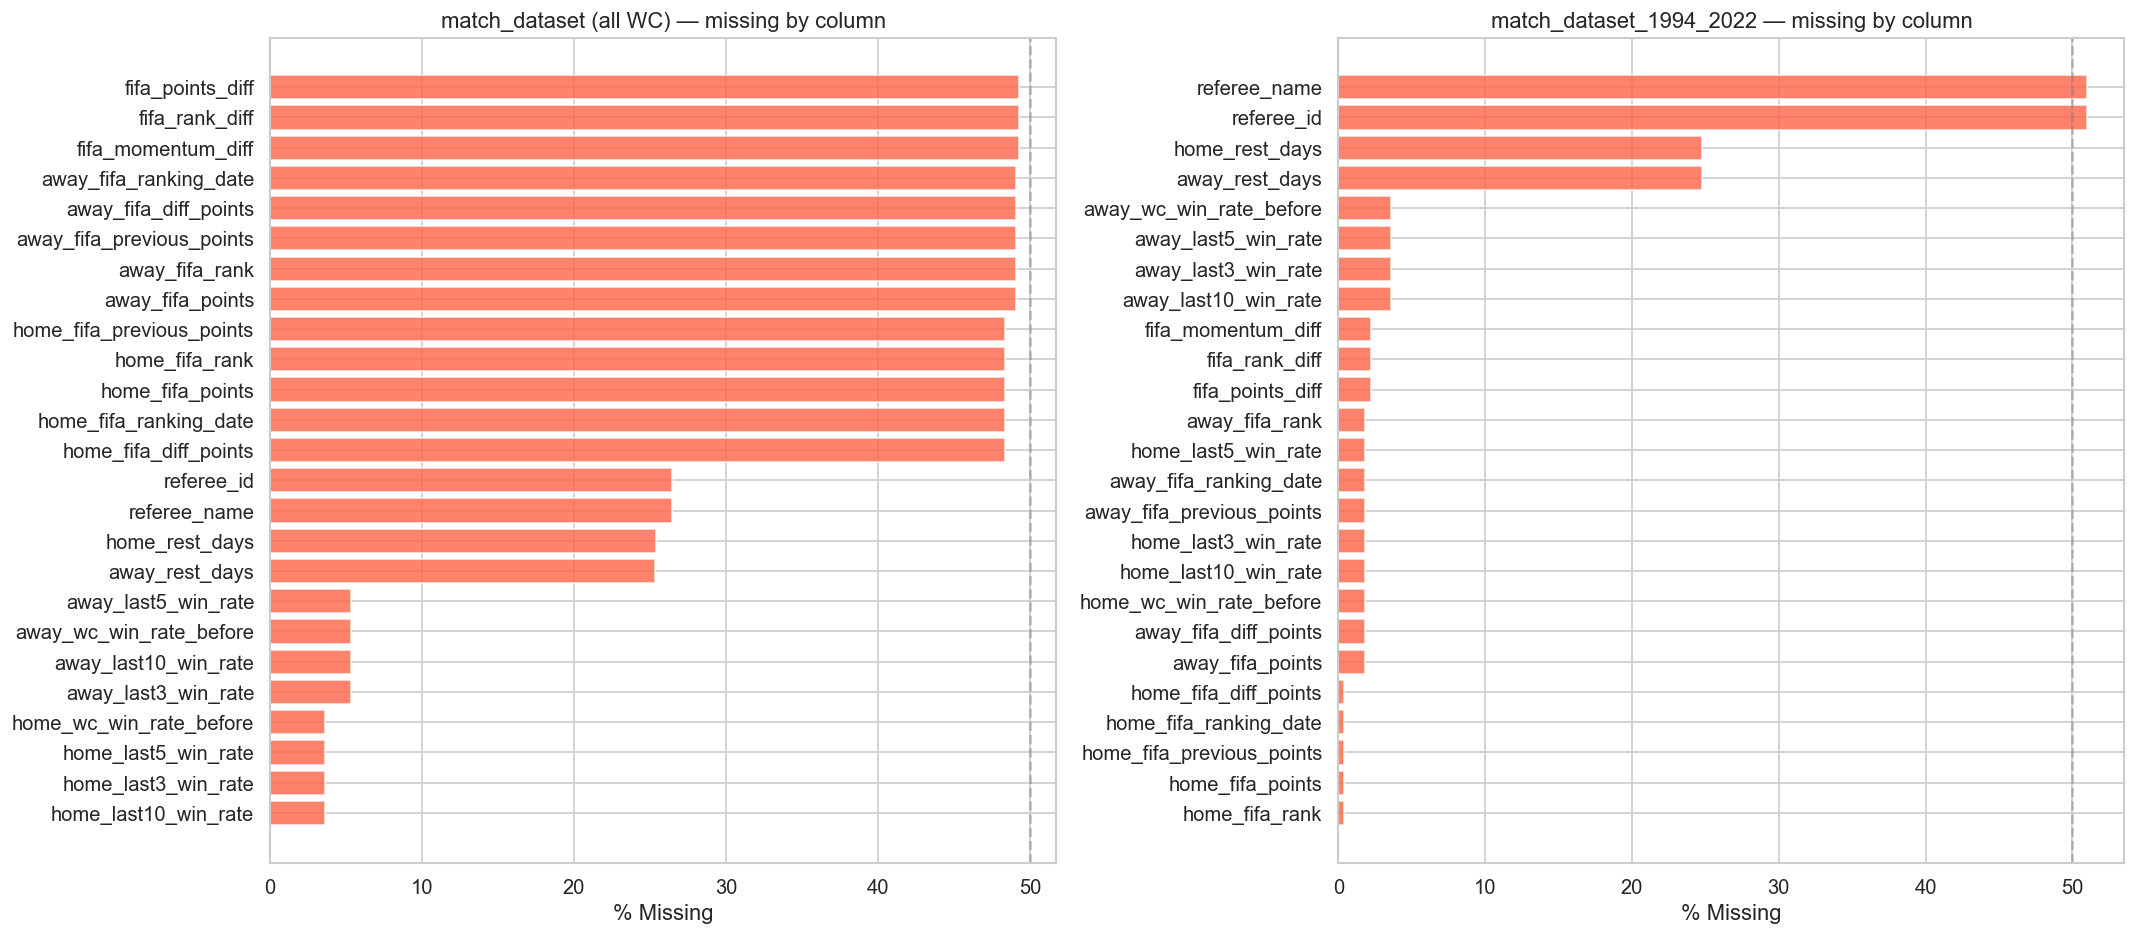


Total null counts in match_dataset_1994_2022 (columns with any nulls):
referee_name                 255
referee_id                   255
away_rest_days               124
home_rest_days               124
away_wc_win_rate_before       18
away_last3_win_rate           18
away_last10_win_rate          18
away_last5_win_rate           18
fifa_rank_diff                11
fifa_momentum_diff            11
fifa_points_diff              11
away_fifa_diff_points          9
home_last3_win_rate            9
away_fifa_previous_points      9
away_fifa_rank                 9
away_fifa_points               9
away_fifa_ranking_date         9
home_last5_win_rate            9
home_wc_win_rate_before        9
home_last10_win_rate           9
home_fifa_diff_points          2
home_fifa_rank                 2
home_fifa_ranking_date         2
home_fifa_points               2
home_fifa_previous_points      2


In [15]:
def plot_missing(df, title, ax, threshold=0):
    missing = df.isnull().mean().sort_values(ascending=False)
    missing = missing[missing > threshold]
    if missing.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    ax.barh(missing.index[::-1], missing.values[::-1] * 100, color='tomato', alpha=0.8)
    ax.set_xlabel('% Missing')
    ax.set_title(title)
    ax.axvline(50, color='gray', linestyle='--', alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_missing(df_all, 'match_dataset (all WC) — missing by column', axes[0], threshold=0.001)
plot_missing(df94,  'match_dataset_1994_2022 — missing by column', axes[1], threshold=0.001)
plt.tight_layout()
plt.show()

print('\nTotal null counts in match_dataset_1994_2022 (columns with any nulls):')
nulls = df94.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False).to_string())

## 7. Feature Correlations with Target

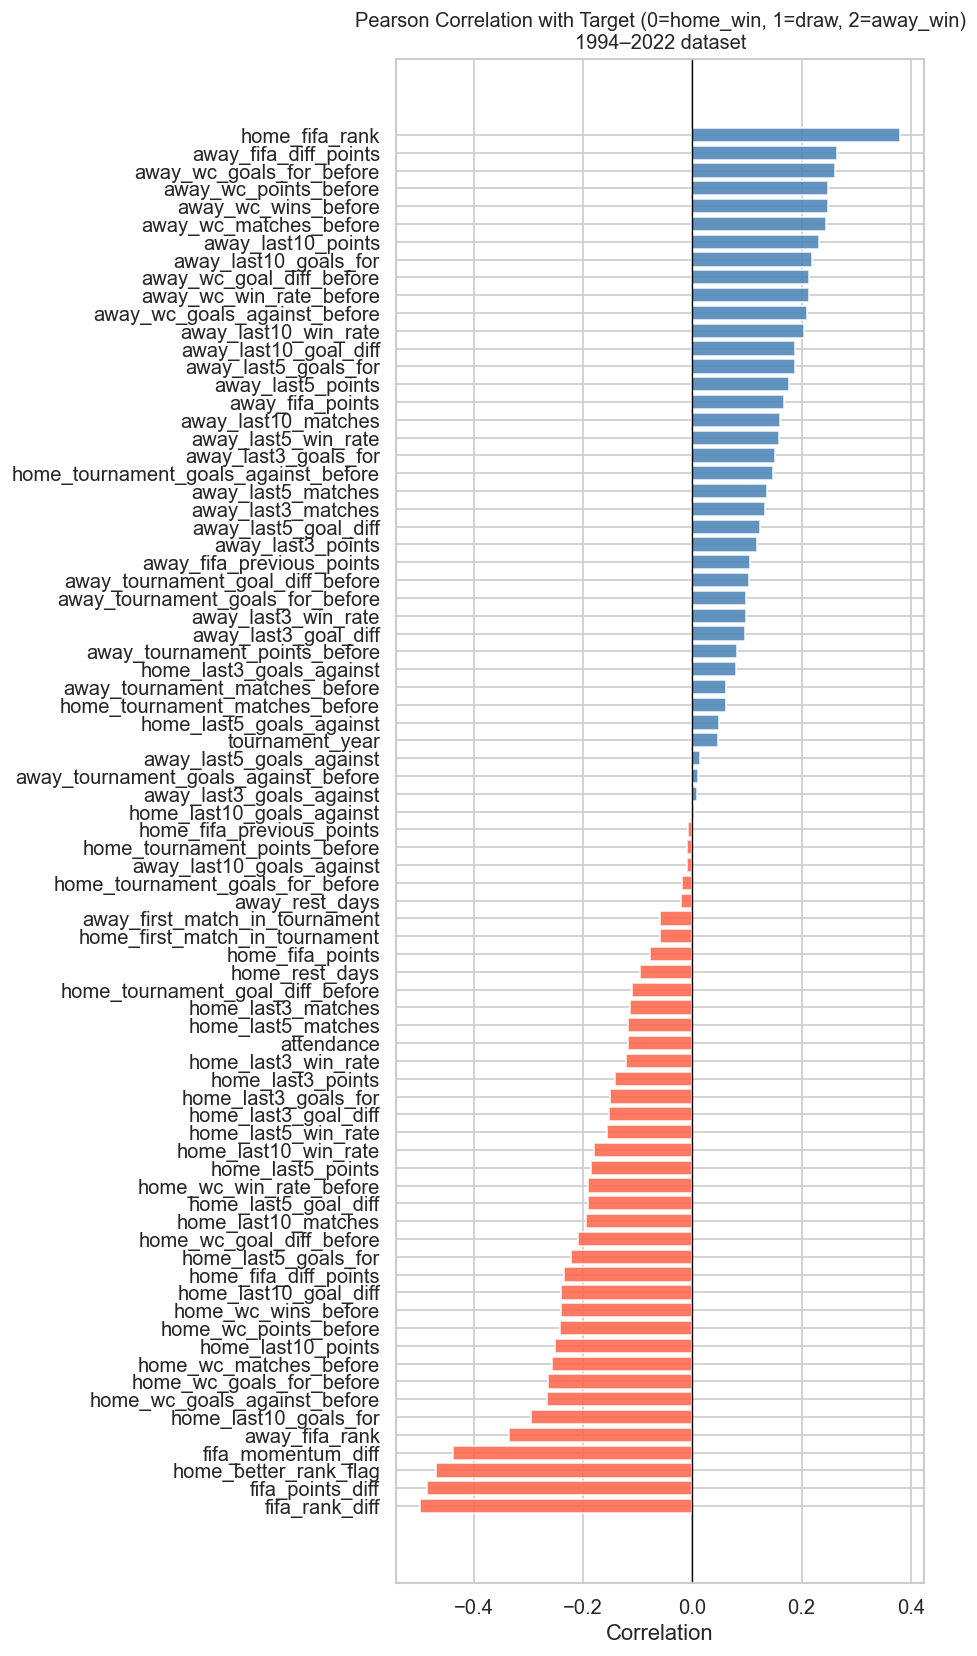

Top 5 positive (away-win associated):
away_wc_wins_before         0.248
away_wc_points_before       0.249
away_wc_goals_for_before    0.261
away_fifa_diff_points       0.265
home_fifa_rank              0.381

Top 5 negative (home-win associated):
fifa_rank_diff          -0.499
fifa_points_diff        -0.485
home_better_rank_flag   -0.470
fifa_momentum_diff      -0.438
away_fifa_rank          -0.335


In [16]:
# Build numeric-only feature matrix for 1994–2022
exclude = ['target', 'home_score', 'away_score',  # direct leakage
           'tournament_id', 'match_id', 'home_team_id', 'away_team_id',
           'stadium_id', 'referee_id', 'home_manager_id', 'away_manager_id',
           'text_available', 'text_count']  # structural, not features

num_feats = [c for c in df94.columns
             if df94[c].dtype in ['float64', 'int64', 'int32', 'int8', 'bool']
             and c not in exclude]

corr_target = df94[num_feats + ['target']].corr()['target'].drop('target').dropna().sort_values()

fig, ax = plt.subplots(figsize=(8, 14))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Target (0=home_win, 1=draw, 2=away_win)\n1994–2022 dataset', fontsize=12)
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print('Top 5 positive (away-win associated):')
print(corr_target.tail(5).round(3).to_string())
print('\nTop 5 negative (home-win associated):')
print(corr_target.head(5).round(3).to_string())

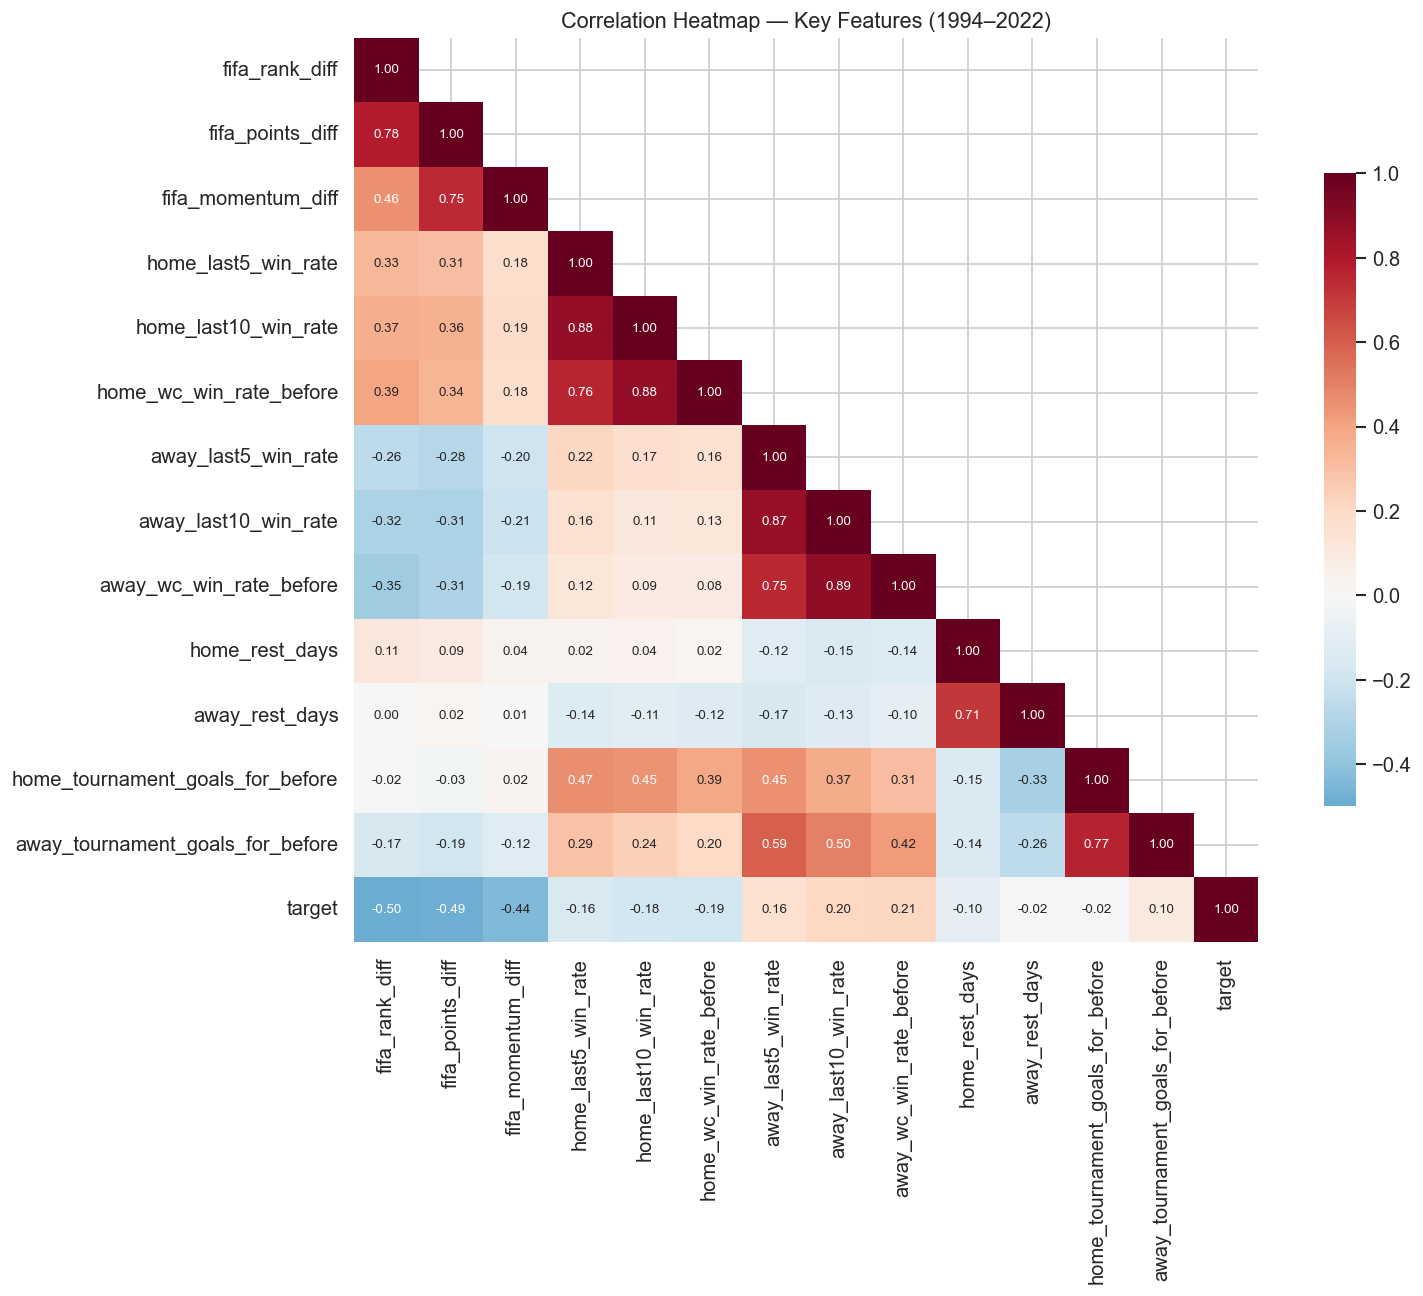

In [17]:
# Heatmap: key feature groups
key_features = [
    'fifa_rank_diff', 'fifa_points_diff', 'fifa_momentum_diff',
    'home_last5_win_rate', 'home_last10_win_rate', 'home_wc_win_rate_before',
    'away_last5_win_rate', 'away_last10_win_rate', 'away_wc_win_rate_before',
    'home_rest_days', 'away_rest_days',
    'home_tournament_goals_for_before', 'away_tournament_goals_for_before',
    'target'
]
corr_mat = df94[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, mask=mask,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Key Features (1994–2022)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Team-Level Analysis

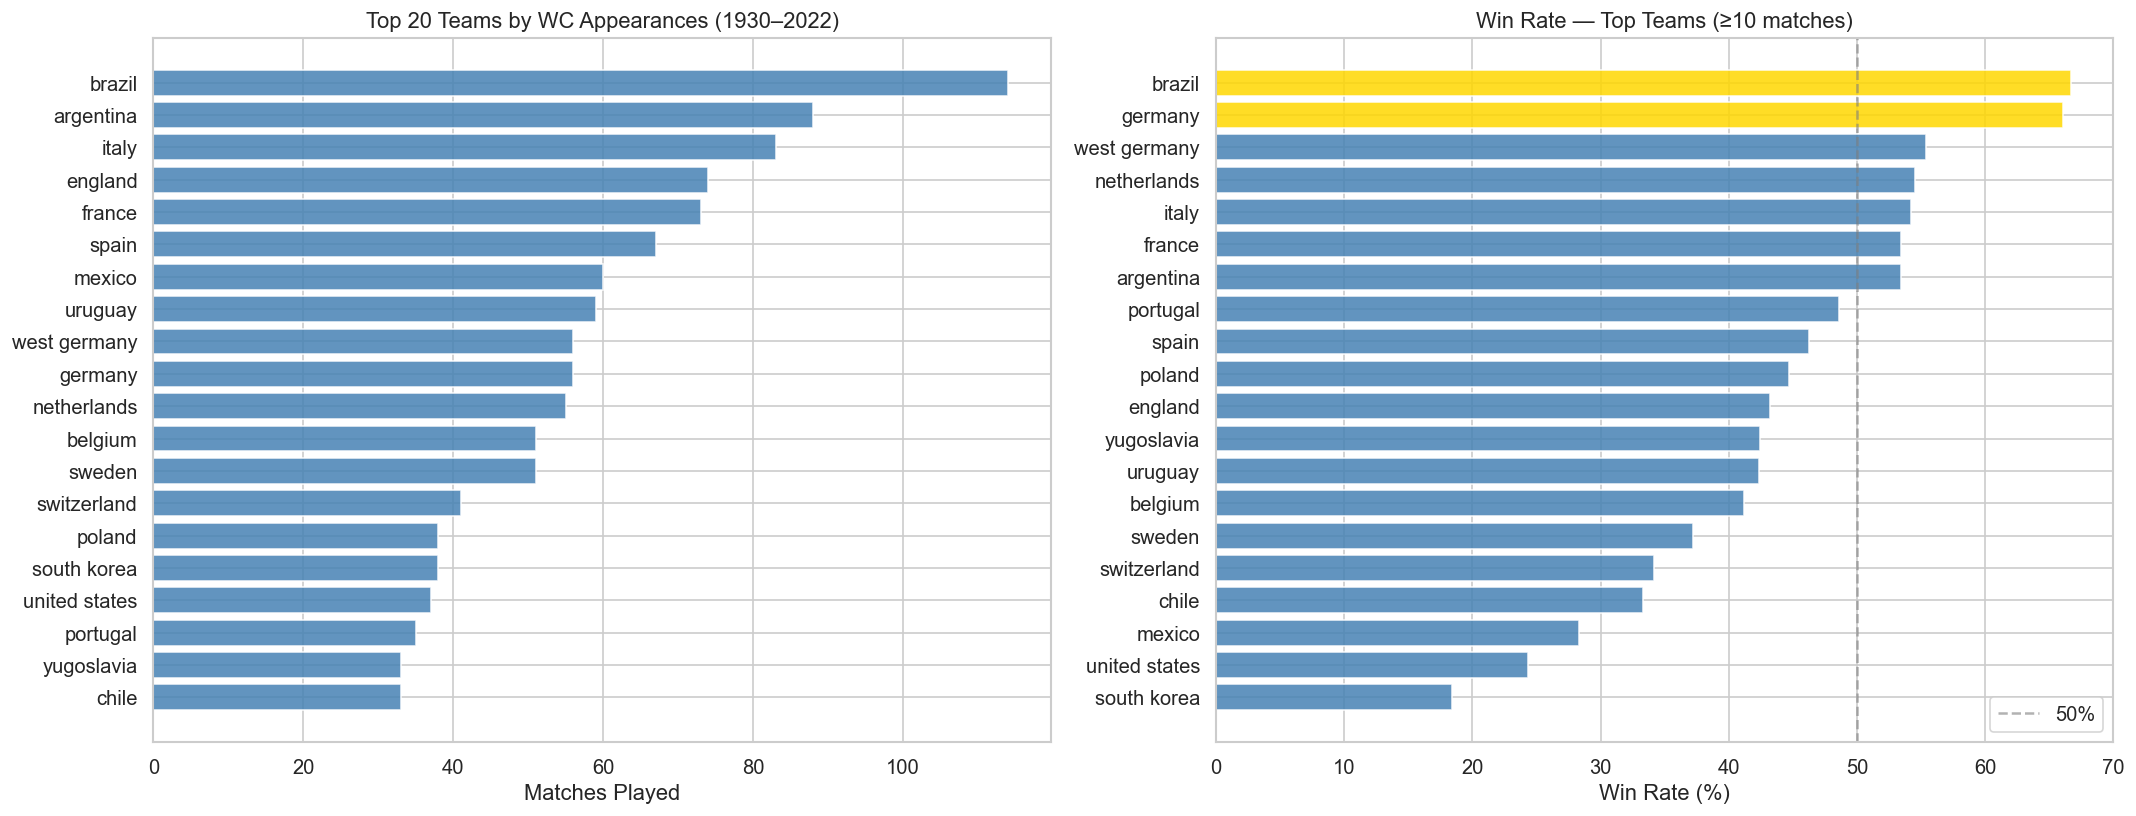

In [18]:
# Most appearances
home_apps = df_all['home_team_norm'].value_counts()
away_apps = df_all['away_team_norm'].value_counts()
total_apps = (home_apps.add(away_apps, fill_value=0)).sort_values(ascending=False)

# Win rates per team (from home and away perspective)
home_wins = df_all[df_all['result']=='home_win'].groupby('home_team_norm').size()
away_wins = df_all[df_all['result']=='away_win'].groupby('away_team_norm').size()
total_wins = home_wins.add(away_wins, fill_value=0)

team_stats = pd.DataFrame({'appearances': total_apps, 'wins': total_wins}).dropna()
team_stats['win_rate'] = team_stats['wins'] / team_stats['appearances']
team_stats = team_stats.sort_values('appearances', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top teams by appearances
top20 = team_stats.head(20)
axes[0].barh(top20.index[::-1], top20['appearances'][::-1], color='steelblue', alpha=0.85)
axes[0].set_title('Top 20 Teams by WC Appearances (1930–2022)')
axes[0].set_xlabel('Matches Played')

# Win rate for teams with 10+ matches
wr = team_stats[team_stats['appearances'] >= 10].sort_values('win_rate', ascending=False).head(20)
colors_bar = ['gold' if w > 0.6 else 'steelblue' for w in wr['win_rate']]
axes[1].barh(wr.index[::-1], wr['win_rate'][::-1] * 100, color=colors_bar[::-1], alpha=0.85)
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.6, label='50%')
axes[1].set_title('Win Rate — Top Teams (≥10 matches)')
axes[1].set_xlabel('Win Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

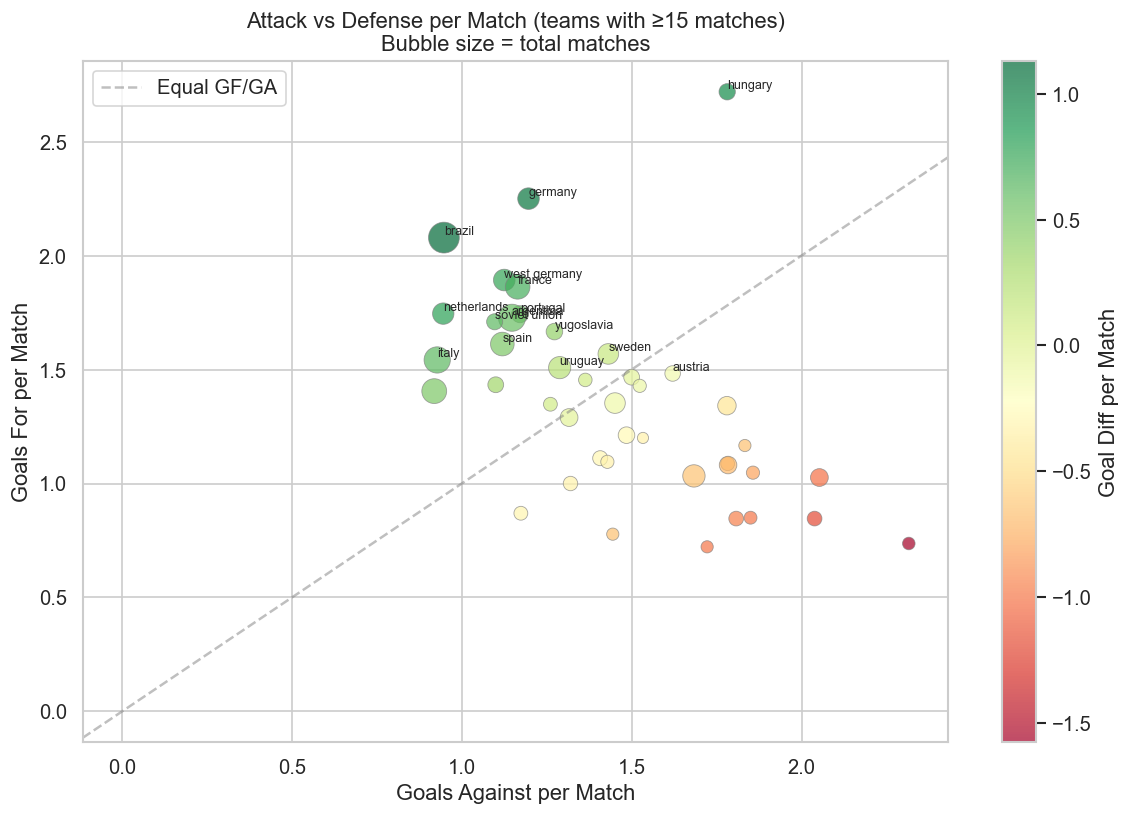

In [19]:
# Goals for/against per team
home_gf = df_all.groupby('home_team_norm')['home_score'].sum()
away_gf = df_all.groupby('away_team_norm')['away_score'].sum()
home_ga = df_all.groupby('home_team_norm')['away_score'].sum()
away_ga = df_all.groupby('away_team_norm')['home_score'].sum()

gf = home_gf.add(away_gf, fill_value=0)
ga = home_ga.add(away_ga, fill_value=0)
apps_all = total_apps

team_goals = pd.DataFrame({'gf_per_match': gf / apps_all, 'ga_per_match': ga / apps_all}).dropna()
team_goals = team_goals[apps_all >= 15].sort_values('gf_per_match', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(team_goals['ga_per_match'], team_goals['gf_per_match'],
                     s=apps_all[team_goals.index] * 3, alpha=0.7,
                     c=team_goals['gf_per_match'] - team_goals['ga_per_match'],
                     cmap='RdYlGn', edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='Goal Diff per Match')

for team in team_goals.head(15).index:
    ax.annotate(team, (team_goals.loc[team, 'ga_per_match'], team_goals.loc[team, 'gf_per_match']),
                fontsize=7.5, ha='left', va='bottom')

ax.axline((0,0), slope=1, color='gray', linestyle='--', alpha=0.5, label='Equal GF/GA')
ax.set_xlabel('Goals Against per Match')
ax.set_ylabel('Goals For per Match')
ax.set_title('Attack vs Defense per Match (teams with ≥15 matches)\nBubble size = total matches')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Attendance Analysis

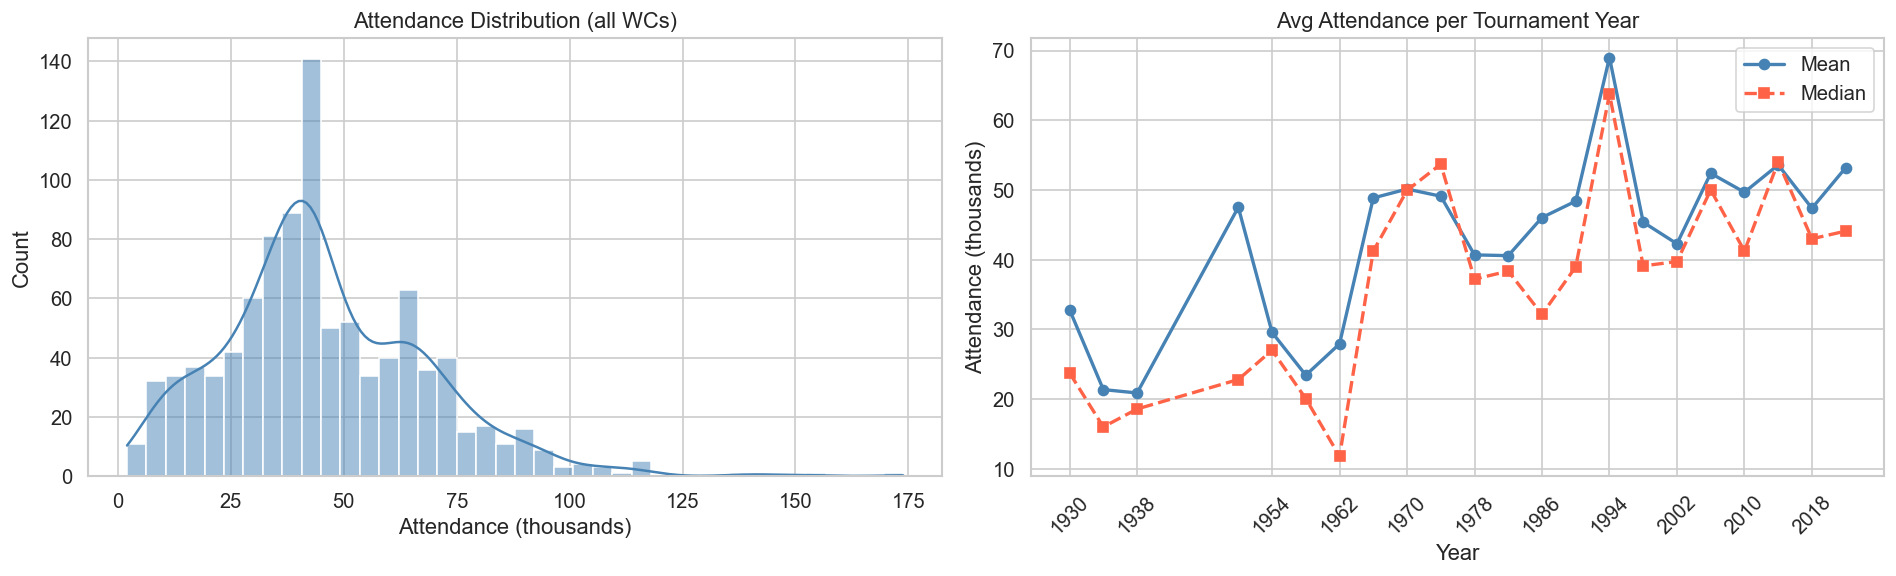

Highest attended match: {'tournament_year': 1950, 'home_team_norm': 'uruguay', 'away_team_norm': 'brazil', 'attendance': 173850}
Lowest attended match: {'tournament_year': 1930, 'home_team_norm': 'chile', 'away_team_norm': 'france', 'attendance': 2000}


In [20]:
df_att = df_all.dropna(subset=['attendance'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Attendance distribution
sns.histplot(df_att['attendance'] / 1000, bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Attendance Distribution (all WCs)')
axes[0].set_xlabel('Attendance (thousands)')

# Average attendance per year
att_yr = df_att.groupby('tournament_year')['attendance'].agg(['mean','median'])
axes[1].plot(att_yr.index, att_yr['mean'] / 1000, 'o-', label='Mean', color='steelblue', linewidth=2)
axes[1].plot(att_yr.index, att_yr['median'] / 1000, 's--', label='Median', color='tomato', linewidth=2)
axes[1].set_title('Avg Attendance per Tournament Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Attendance (thousands)')
axes[1].legend()
axes[1].set_xticks(att_yr.index[::2])
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print(f'Highest attended match: {df_att.loc[df_att["attendance"].idxmax(), ["tournament_year","home_team_norm","away_team_norm","attendance"]].to_dict()}')
print(f'Lowest attended match: {df_att.loc[df_att["attendance"].idxmin(), ["tournament_year","home_team_norm","away_team_norm","attendance"]].to_dict()}')

## 10. Text Data & Article Coverage

In [21]:
print('Articles dataset shape:', df_arts.shape)
print('Source breakdown:', df_arts['source'].value_counts().to_dict())
print('All articles are pre-match:', df_arts['is_pre_match'].all())
print('Any leakage risk:', df_arts['leakage_risk_flag'].any())
print()
print('Hours before match stats:')
print(df_arts['hours_before_match'].describe().round(2))

# Text length
df_arts['text_len'] = df_arts['clean_text'].fillna('').str.len()
print('\nArticle text length (chars):')
print(df_arts['text_len'].describe().round(0))

Articles dataset shape: (994, 26)
Source breakdown: {'guardian': 994}
All articles are pre-match: True
Any leakage risk: False

Hours before match stats:
count    994.00
mean      85.64
std       77.23
min        0.17
25%       19.65
50%       76.14
75%      110.02
max      329.77
Name: hours_before_match, dtype: float64

Article text length (chars):
count      994.0
mean      8853.0
std       9926.0
min        129.0
25%       2214.0
50%       4540.0
75%      12977.0
max      51414.0
Name: text_len, dtype: float64


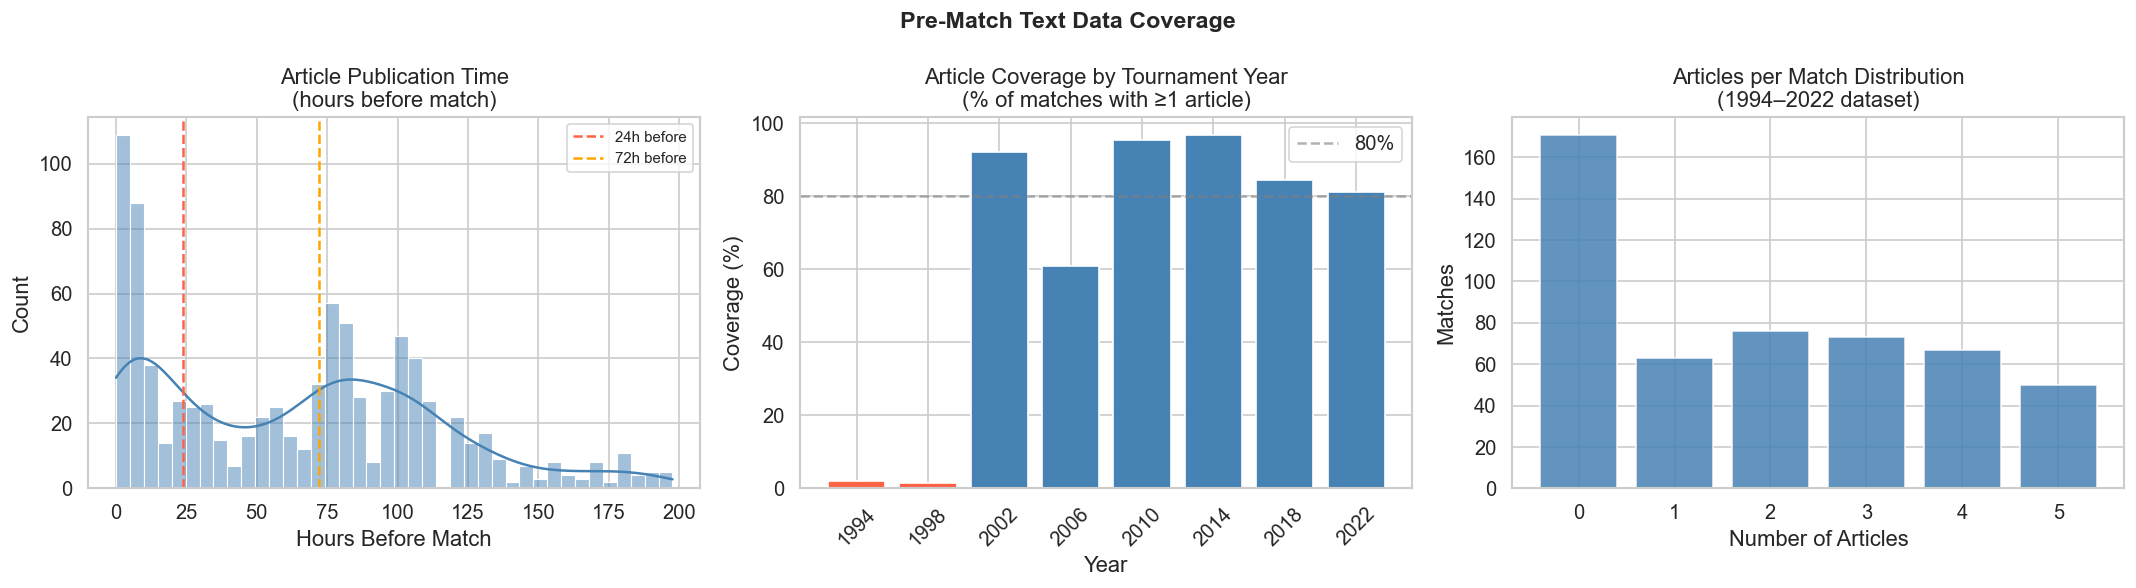

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hours before match distribution
hours = df_arts['hours_before_match']
sns.histplot(hours[hours <= 200], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(24, color='tomato', linestyle='--', label='24h before')
axes[0].axvline(72, color='orange', linestyle='--', label='72h before')
axes[0].set_title('Article Publication Time\n(hours before match)')
axes[0].set_xlabel('Hours Before Match')
axes[0].legend(fontsize=9)

# Text availability by tournament year
text_yr = df_text.groupby('tournament_year').agg(
    total=('match_id', 'count'),
    with_text=('text_available', 'sum')
).reset_index()
text_yr['coverage'] = text_yr['with_text'] / text_yr['total']

axes[1].bar(text_yr['tournament_year'].astype(str), text_yr['coverage'] * 100,
            color=['tomato' if c < 0.5 else 'steelblue' for c in text_yr['coverage']])
axes[1].set_title('Article Coverage by Tournament Year\n(% of matches with ≥1 article)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Coverage (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.6, label='80%')
axes[1].legend()

# Article count per match
text_counts = df_text['text_count'].value_counts().sort_index()
axes[2].bar(text_counts.index, text_counts.values, color='steelblue', alpha=0.85)
axes[2].set_title('Articles per Match Distribution\n(1994–2022 dataset)')
axes[2].set_xlabel('Number of Articles')
axes[2].set_ylabel('Matches')

fig.suptitle('Pre-Match Text Data Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

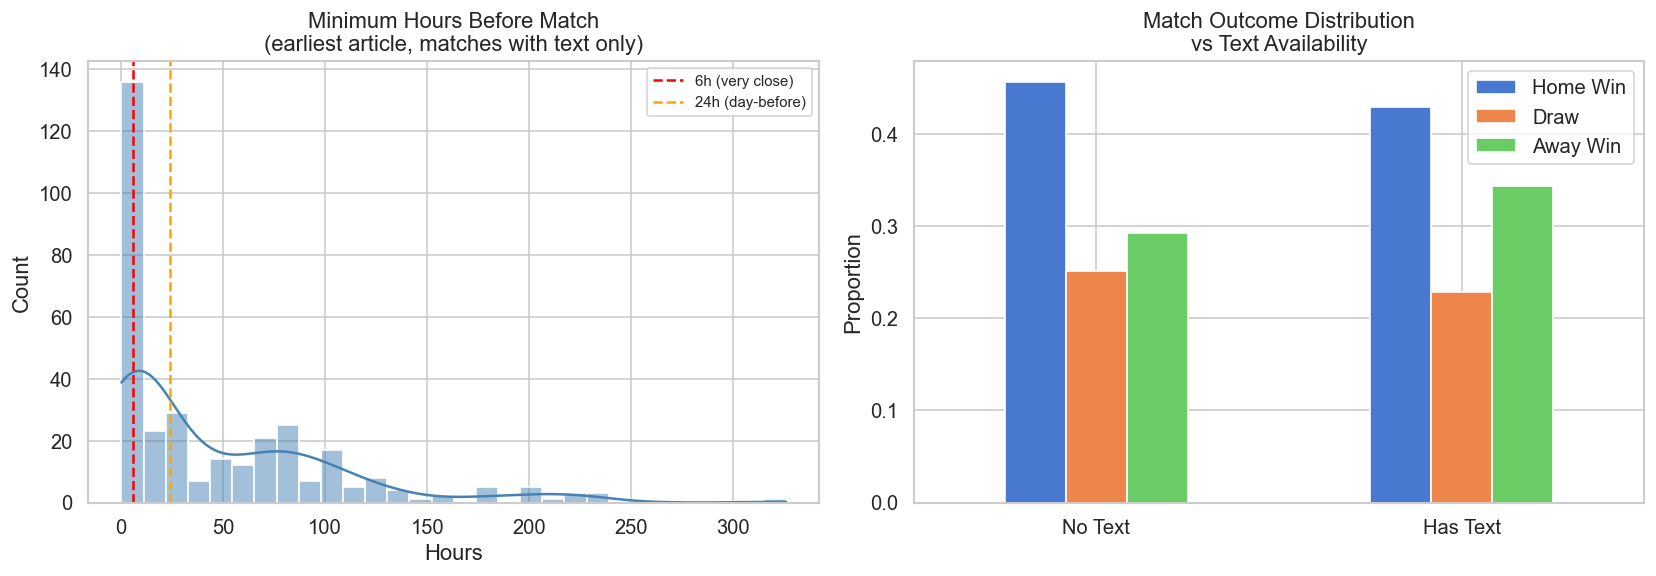

In [23]:
# Min hours before match per match (1994-2022 with text)
has_text = df_text[df_text['text_available'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of minimum hours before match
sns.histplot(has_text['min_hours_before_match'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(6, color='red', linestyle='--', label='6h (very close)')
axes[0].axvline(24, color='orange', linestyle='--', label='24h (day-before)')
axes[0].set_title('Minimum Hours Before Match\n(earliest article, matches with text only)')
axes[0].set_xlabel('Hours')
axes[0].legend(fontsize=9)

# Text availability vs match outcome
text_outcome = df_text.groupby(['text_available', 'result']).size().unstack(fill_value=0)
text_outcome_pct = text_outcome.div(text_outcome.sum(axis=1), axis=0)
text_outcome_pct.index = ['No Text', 'Has Text']
text_outcome_pct[['home_win','draw','away_win']].plot(kind='bar', ax=axes[1],
    color=sns.color_palette('muted', 3), edgecolor='white')
axes[1].set_title('Match Outcome Distribution\nvs Text Availability')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion')
axes[1].legend(['Home Win', 'Draw', 'Away Win'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

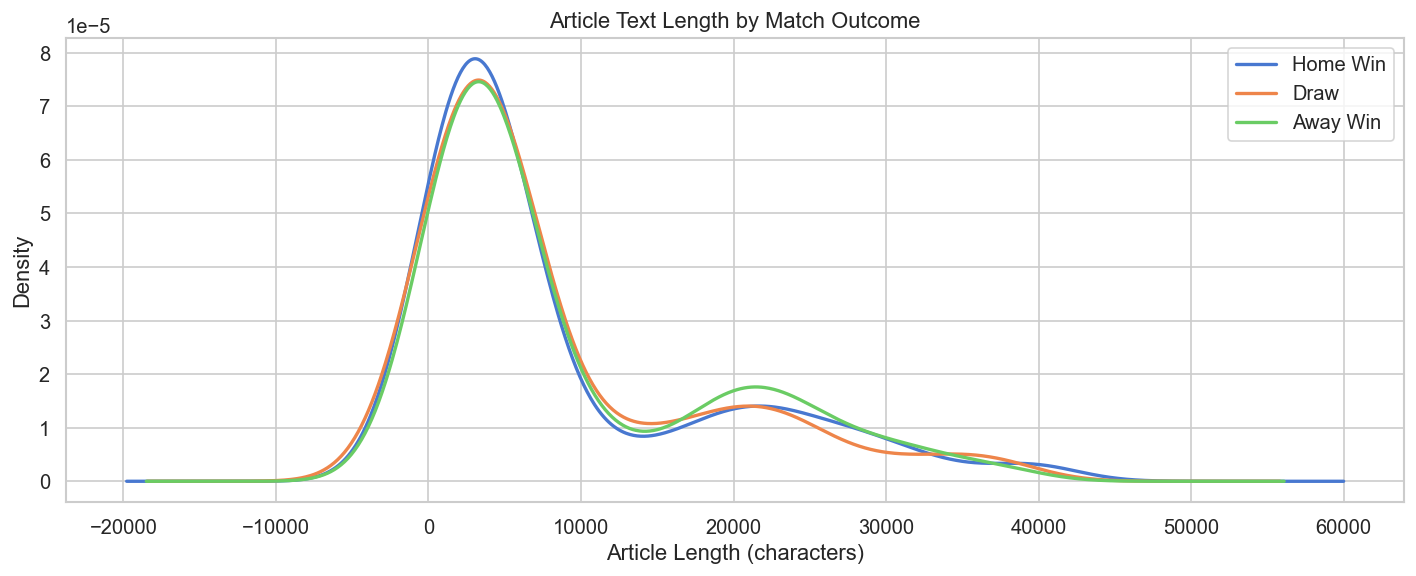

In [24]:
# Article text length distribution by match outcome (merge articles → matches)
arts_match = df_arts.merge(df_text[['match_id','result']], on='match_id', how='left')

fig, ax = plt.subplots(figsize=(12, 5))
for res, label, color in zip(['home_win','draw','away_win'],
                               ['Home Win','Draw','Away Win'],
                               sns.color_palette('muted', 3)):
    subset = arts_match[arts_match['result']==res]['text_len'].dropna()
    if not subset.empty:
        subset.clip(upper=subset.quantile(0.99)).plot.kde(ax=ax, label=label, color=color, linewidth=2)

ax.set_title('Article Text Length by Match Outcome')
ax.set_xlabel('Article Length (characters)')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Tournament & Stage Analysis

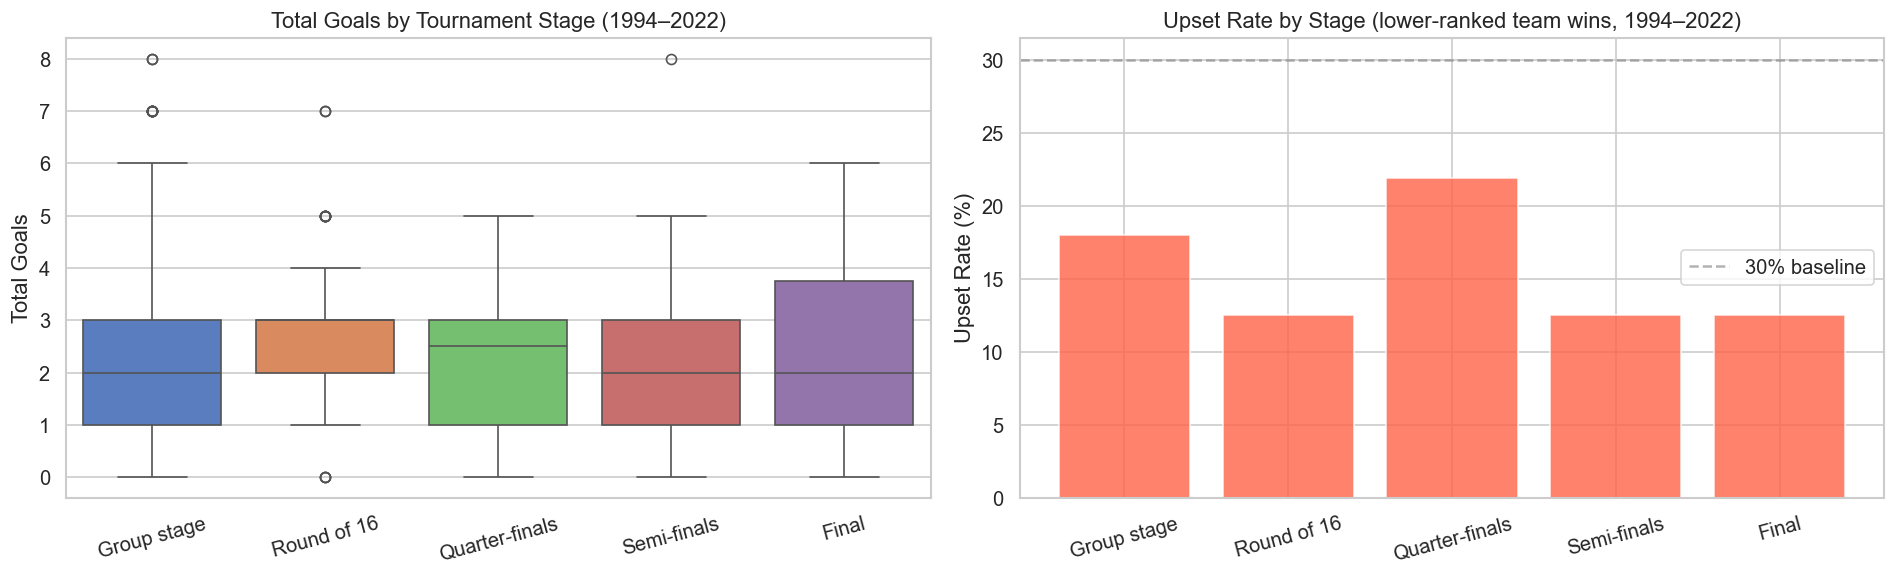

In [25]:
stages_main = ['Group stage', 'Round of 16', 'Quarter-finals', 'Semi-finals', 'Final']
df_stages = df94[df94['stage'].isin(stages_main)].copy()
df_stages['total_goals'] = df_stages['home_score'] + df_stages['away_score']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Goals by stage
sns.boxplot(data=df_stages, x='stage', y='total_goals', order=stages_main,
            palette='muted', ax=axes[0])
axes[0].set_title('Total Goals by Tournament Stage (1994–2022)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Goals')
axes[0].tick_params(axis='x', rotation=15)

# Upset rate by stage (lower ranked team winning)
upset_data = df94[df94['stage'].isin(stages_main)].dropna(subset=['home_better_rank_flag'])
upset_data = upset_data.copy()
upset_data['upset'] = (
    (upset_data['home_better_rank_flag'] == 1) & (upset_data['result'] == 'away_win') |
    (upset_data['home_better_rank_flag'] == 0) & (upset_data['result'] == 'home_win')
)
upset_by_stage = upset_data.groupby('stage')['upset'].mean().reindex(stages_main).dropna()
axes[1].bar(upset_by_stage.index, upset_by_stage.values * 100, color='tomato', alpha=0.8)
axes[1].axhline(30, color='gray', linestyle='--', alpha=0.6, label='30% baseline')
axes[1].set_title('Upset Rate by Stage (lower-ranked team wins, 1994–2022)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Upset Rate (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 12. Feature Group Importance Proxy (Variance & Separability)

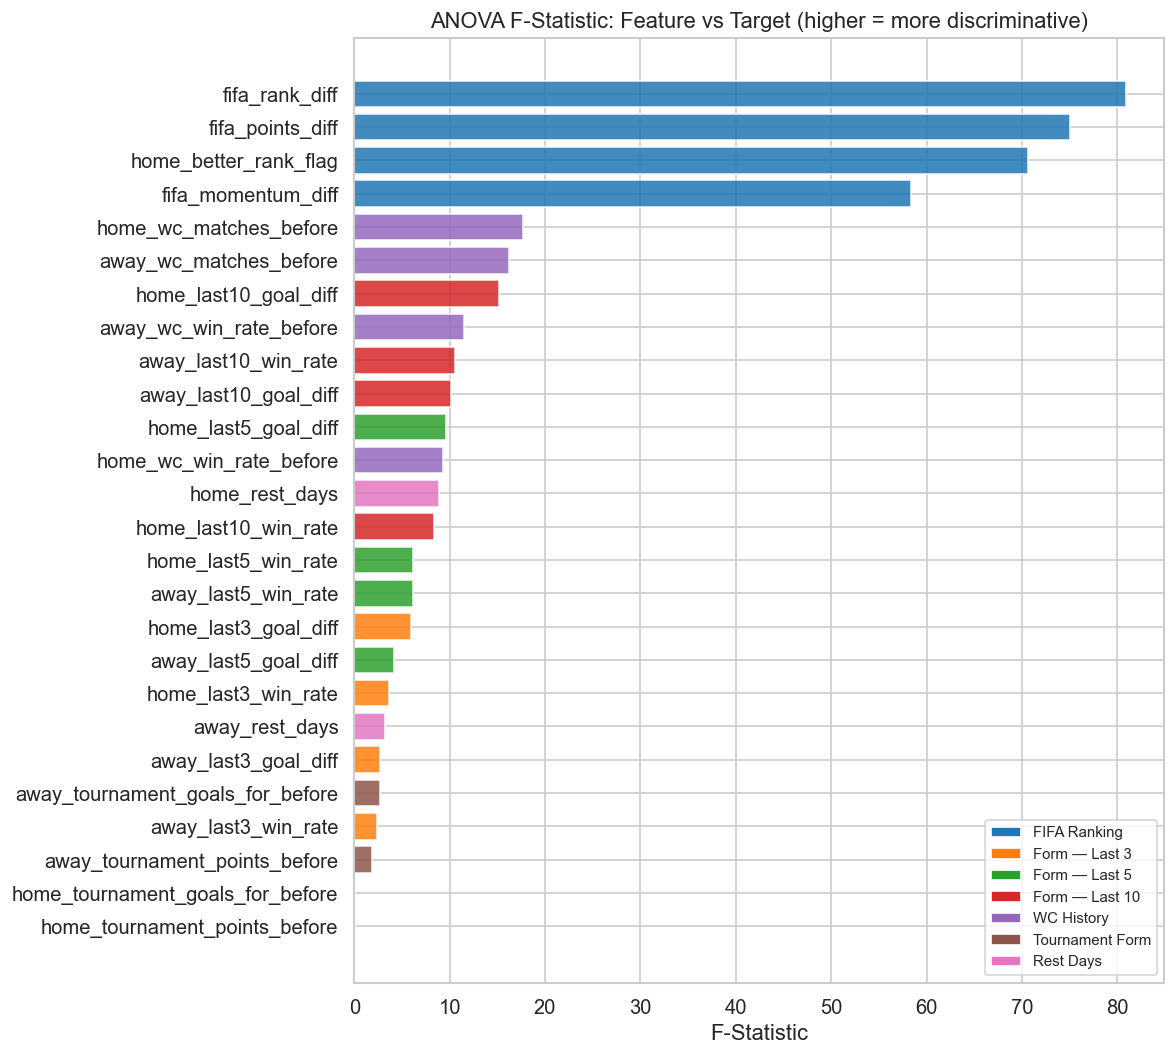

Top 10 most discriminative features:
                Feature          Group    F-stat      p-value
         fifa_rank_diff   FIFA Ranking 80.902758 4.694243e-31
       fifa_points_diff   FIFA Ranking 75.092949 3.816736e-29
  home_better_rank_flag   FIFA Ranking 70.638673 9.993538e-28
     fifa_momentum_diff   FIFA Ranking 58.359412 1.926317e-23
 home_wc_matches_before     WC History 17.653130 3.921132e-08
 away_wc_matches_before     WC History 16.183905 1.551732e-07
  home_last10_goal_diff Form — Last 10 15.219167 3.845009e-07
away_wc_win_rate_before     WC History 11.539133 1.275263e-05
   away_last10_win_rate Form — Last 10 10.544370 3.300506e-05
  away_last10_goal_diff Form — Last 10 10.146743 4.796405e-05


In [26]:
from scipy.stats import f_oneway

# One-way ANOVA F-statistic for numeric features vs target
feature_groups = {
    'FIFA Ranking': ['fifa_rank_diff', 'fifa_points_diff', 'fifa_momentum_diff', 'home_better_rank_flag'],
    'Form — Last 3': ['home_last3_win_rate', 'away_last3_win_rate', 'home_last3_goal_diff', 'away_last3_goal_diff'],
    'Form — Last 5': ['home_last5_win_rate', 'away_last5_win_rate', 'home_last5_goal_diff', 'away_last5_goal_diff'],
    'Form — Last 10': ['home_last10_win_rate', 'away_last10_win_rate', 'home_last10_goal_diff', 'away_last10_goal_diff'],
    'WC History': ['home_wc_win_rate_before', 'away_wc_win_rate_before', 'home_wc_matches_before', 'away_wc_matches_before'],
    'Tournament Form': ['home_tournament_goals_for_before', 'away_tournament_goals_for_before',
                        'home_tournament_points_before', 'away_tournament_points_before'],
    'Rest Days': ['home_rest_days', 'away_rest_days'],
}

anova_results = []
for group_name, cols in feature_groups.items():
    for col in cols:
        d = df94[[col, 'target']].dropna()
        if len(d) < 30:
            continue
        groups = [d[d['target'] == t][col].values for t in sorted(d['target'].unique())]
        if any(len(g) < 5 for g in groups):
            continue
        f_stat, p_val = f_oneway(*groups)
        anova_results.append({'Feature': col, 'Group': group_name, 'F-stat': f_stat, 'p-value': p_val})

anova_df = pd.DataFrame(anova_results).sort_values('F-stat', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors_group = sns.color_palette('tab10', len(feature_groups))
group_color = {g: c for g, c in zip(feature_groups.keys(), colors_group)}
bar_colors = [group_color[g] for g in anova_df['Group']]
ax.barh(anova_df['Feature'][::-1], anova_df['F-stat'][::-1], color=bar_colors[::-1], alpha=0.85)
ax.set_title('ANOVA F-Statistic: Feature vs Target (higher = more discriminative)')
ax.set_xlabel('F-Statistic')

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=group_color[g], label=g) for g in feature_groups]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 10 most discriminative features:')
print(anova_df[['Feature','Group','F-stat','p-value']].head(10).to_string(index=False))

## 13. Class Balance & Stratification

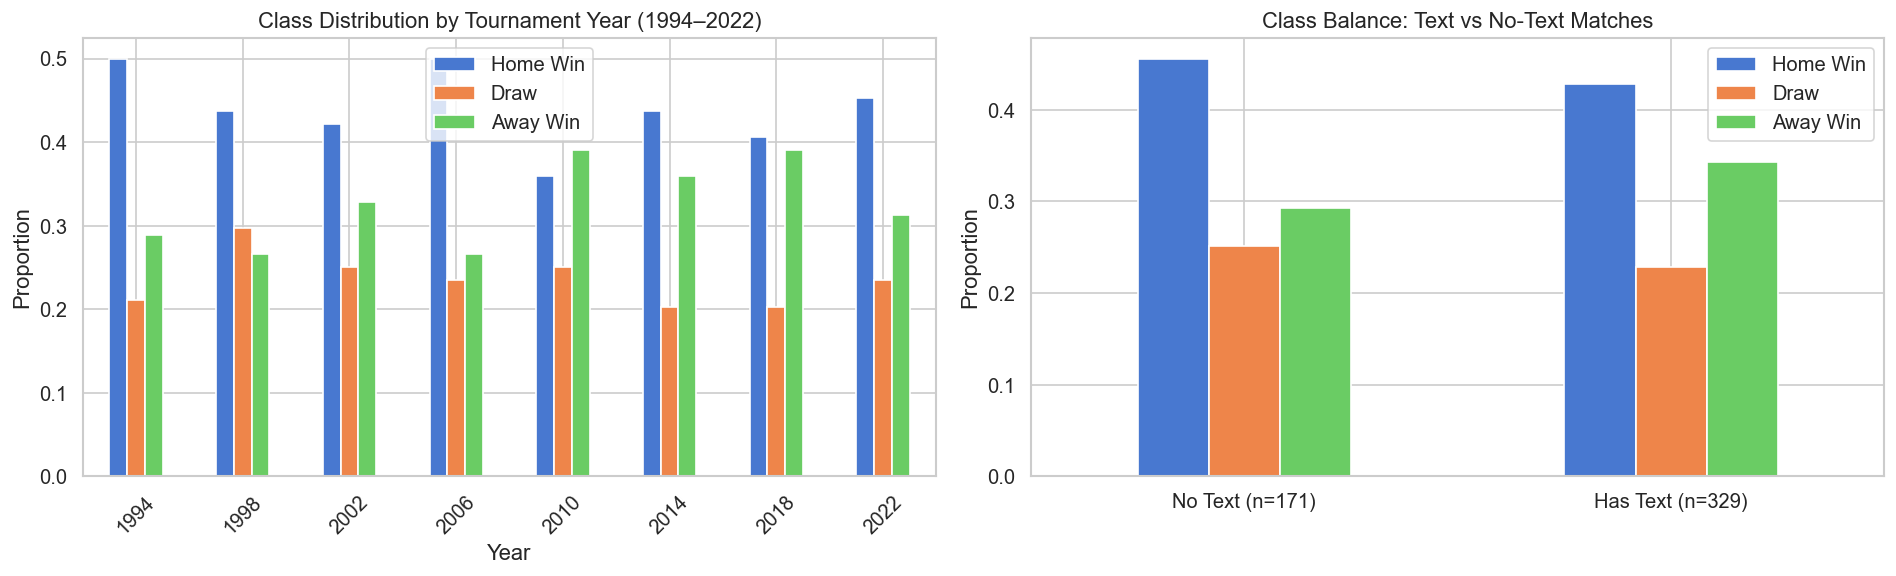

Overall class balance (1994–2022):
result
home_win    0.438
away_win    0.326
draw        0.236
Name: proportion, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Class balance by year
yr_result_94 = df94.groupby('tournament_year')['result'].value_counts().unstack().fillna(0)
yr_result_94_pct = yr_result_94.div(yr_result_94.sum(axis=1), axis=0)
yr_result_94_pct[['home_win','draw','away_win']].plot(kind='bar', ax=axes[0],
    color=sns.color_palette('muted', 3), edgecolor='white')
axes[0].set_title('Class Distribution by Tournament Year (1994–2022)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Proportion')
axes[0].legend(['Home Win', 'Draw', 'Away Win'])
axes[0].tick_params(axis='x', rotation=45)

# Class balance with vs without text
text_result = df_text.groupby(['text_available', 'result']).size().unstack(fill_value=0)
text_result_pct = text_result.div(text_result.sum(axis=1), axis=0)
text_result_pct.index = ['No Text (n=171)', f'Has Text (n=329)']
text_result_pct[['home_win','draw','away_win']].plot(kind='bar', ax=axes[1],
    color=sns.color_palette('muted', 3), edgecolor='white')
axes[1].set_title('Class Balance: Text vs No-Text Matches')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion')
axes[1].legend(['Home Win', 'Draw', 'Away Win'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Overall class balance (1994–2022):')
print(df94['result'].value_counts(normalize=True).round(3))

## 14. Summary & Key Findings

In [28]:
print("="*70)
print("KEY EDA FINDINGS")
print("="*70)
print()
print("1. CLASS IMBALANCE")
vc = df94['result'].value_counts(normalize=True)
print(f"   Home win: {vc.get('home_win',0)*100:.1f}%  |  Draw: {vc.get('draw',0)*100:.1f}%  |  Away win: {vc.get('away_win',0)*100:.1f}%")
print("   → Moderate imbalance; consider weighted loss or stratified splits.")
print()
print("2. FIFA RANKINGS ARE HIGHLY PREDICTIVE (1994–2022)")
d = df94.dropna(subset=['fifa_rank_diff'])
hw_when_better = (d[d['fifa_rank_diff'] < -20]['result'] == 'home_win').mean()
print(f"   When home team much better ranked: home wins {hw_when_better*100:.0f}% of the time")
print(f"   Pearson corr(fifa_rank_diff, target): {df94['fifa_rank_diff'].corr(df94['target']):.3f}")
print()
print("3. HOME ADVANTAGE HAS DECLINED OVER TIME")
hw_early = (df_all[df_all['tournament_year'] <= 1970]['result'] == 'home_win').mean()
hw_late  = (df_all[df_all['tournament_year'] >= 2002]['result'] == 'home_win').mean()
print(f"   1930–1970 home win rate: {hw_early*100:.1f}%")
print(f"   2002–2022 home win rate: {hw_late*100:.1f}%")
print()
print("4. TEXT DATA COVERAGE")
text_cov = df_text['text_available'].mean()
print(f"   {text_cov*100:.1f}% of 1994–2022 matches have pre-match articles (329/500)")
print(f"   Mean time of earliest article: {df_text['min_hours_before_match'].mean():.1f}h before match")
print(f"   Source: Guardian only — single-source bias to be aware of")
print()
print("5. MISSING DATA")
print(f"   FIFA rankings: only available from 1994 → 464/964 matches lack ranking features")
print(f"   Rest days: null for first match of each tournament (~25% of rows)")
print(f"   Win rates: null when team has never won (35/500 home, 51/500 away)")
print()
print("6. GOAL PATTERNS")
print(f"   Most common scoreline: {df_all.groupby(['home_score','away_score']).size().idxmax()} ({df_all.groupby(['home_score','away_score']).size().max()} times)")
print(f"   Average goals/match: {df_all['total_goals'].mean():.2f}")
print(f"   Draws average fewer goals ({df_all[df_all['result']=='draw']['total_goals'].mean():.2f}) vs home wins ({df_all[df_all['result']=='home_win']['total_goals'].mean():.2f})")
print()
print("7. FORM WINDOWS")
print("   Last-10 features show higher ANOVA F-stats than last-3, suggesting")
print("   longer history is more stable signal for WC match prediction.")
print("="*70)

KEY EDA FINDINGS

1. CLASS IMBALANCE
   Home win: 43.8%  |  Draw: 23.6%  |  Away win: 32.6%
   → Moderate imbalance; consider weighted loss or stratified splits.

2. FIFA RANKINGS ARE HIGHLY PREDICTIVE (1994–2022)
   When home team much better ranked: home wins 12% of the time
   Pearson corr(fifa_rank_diff, target): -0.499

3. HOME ADVANTAGE HAS DECLINED OVER TIME
   1930–1970 home win rate: 84.1%
   2002–2022 home win rate: 43.0%

4. TEXT DATA COVERAGE
   65.8% of 1994–2022 matches have pre-match articles (329/500)
   Mean time of earliest article: 47.6h before match
   Source: Guardian only — single-source bias to be aware of

5. MISSING DATA
   FIFA rankings: only available from 1994 → 464/964 matches lack ranking features
   Rest days: null for first match of each tournament (~25% of rows)
   Win rates: null when team has never won (35/500 home, 51/500 away)

6. GOAL PATTERNS
   Most common scoreline: (np.int64(1), np.int64(0)) (118 times)
   Average goals/match: 2.82
   Draws ave